In [ ]:
# Actividad de la sesión 4 del módulo 7
# 1. Carga y exploración de los datos
# SUBIR ARCHIVO DESDE TU COMPUTADORA
from google.colab import files
uploaded = files.upload()

# CARGAR EL DATASET
import pandas as pd

df = pd.read_csv('dataset_clientes.csv')
print("Primeras filas del datasetclientes:")
print(df.head())
print("\nValores nulos por columna:")
print(df.isnull().sum())

Saving dataset_clientes.csv to dataset_clientes.csv
Primeras filas del datasetclientes:
   ID_Cliente  Edad  Ingresos_Mensuales  Gasto_Anual  Frecuencia_Compra
0           1    56                8158         2310                  6
1           2    69                8400         7088                  5
2           3    46                4170        19807                 11
3           4    32                3255         5801                  4
4           5    60                2154        15985                 13

Valores nulos por columna:
ID_Cliente            0
Edad                  0
Ingresos_Mensuales    0
Gasto_Anual           0
Frecuencia_Compra     0
dtype: int64


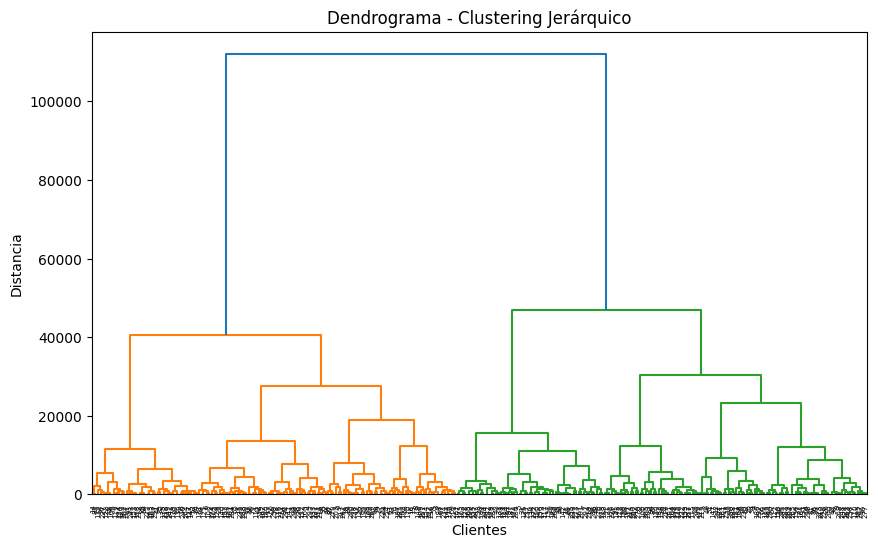

In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Usaremos las variables numéricas para agrupar
X = df[['Edad', 'Ingresos_Mensuales', 'Gasto_Anual', 'Frecuencia_Compra']]

# Enlace jerárquico
linked = linkage(X, method='ward')

# Dendrograma
plt.figure(figsize=(10, 6))
dendrogram(linked)
plt.title('Dendrograma - Clustering Jerárquico')
plt.xlabel('Clientes')
plt.ylabel('Distancia')
plt.show()

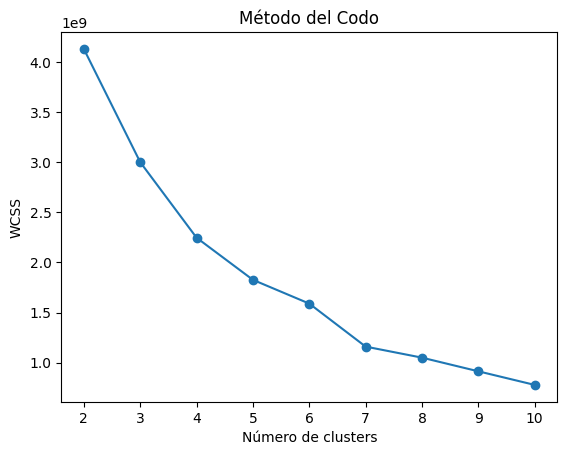

k=2, Silhouette Score=0.496
k=3, Silhouette Score=0.375
k=4, Silhouette Score=0.378
k=5, Silhouette Score=0.373


In [ ]:
# K means con método del codo y silueta
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Método del codo
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

# Silueta
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'k={k}, Silhouette Score={score:.3f}')

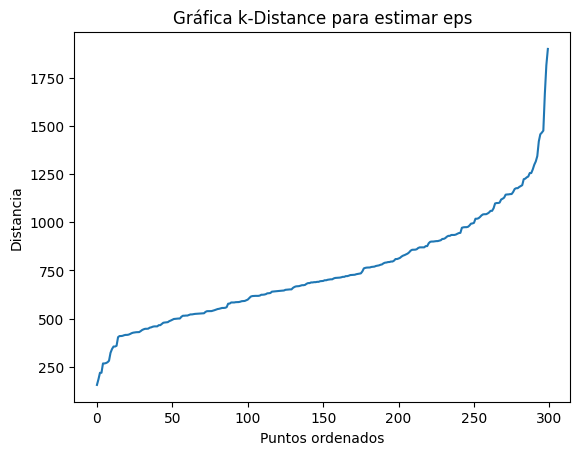

In [ ]:
# DBSCAN con gráfica k-Distance
from sklearn.neighbors import NearestNeighbors
import numpy as np

# k-Distance
neighbors = 4  # min_samples típico = 4
nbrs = NearestNeighbors(n_neighbors=neighbors).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, neighbors-1])

plt.plot(distances)
plt.title('Gráfica k-Distance para estimar eps')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia')
plt.show()

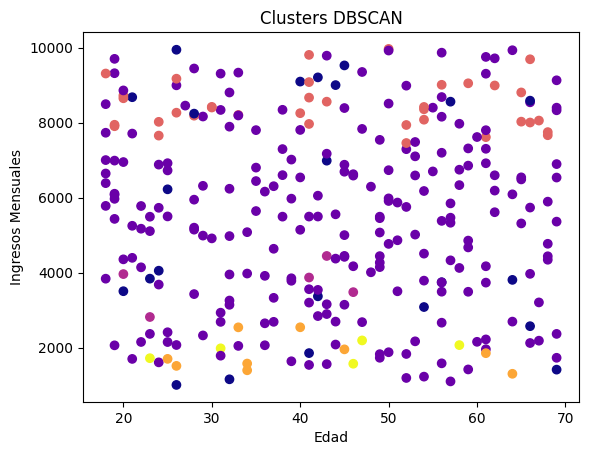

In [ ]:
# DBSCAN con parámetros ajustados
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1000, min_samples=4).fit(X)
labels = db.labels_

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='plasma')
plt.title('Clusters DBSCAN')
plt.xlabel('Edad')
plt.ylabel('Ingresos Mensuales')
plt.show()

Cuando tienes muchas variables —o incluso pocas pero con correlaciones fuertes— aplicar primero una reducción de dimensionalidad como PCA (Análisis de Componentes Principales) antes de usar algoritmos de clustering puede ayudarte mucho:

Por qué PCA puede ayudar en tu caso
Elimina ruido y redundancia: variables muy correlacionadas aportan información duplicada que puede confundir al algoritmo.

Reduce la dimensionalidad: al trabajar en menos dimensiones, K-Means, DBSCAN o Agglomerative suelen encontrar grupos más definidos.

Facilita la visualización: con 2 o 3 componentes principales puedes ver en un gráfico cómo se distribuyen los clusters.

Flujo recomendado
Normalizar las variables numéricas y convertir las categóricas a dummies si es necesario.

Aplicar PCA y quedarte con las primeras componentes que expliquen ~80%–90% de la varianza.

Usar esas componentes como entrada a:

K-Means (con método del codo y silhouette score para elegir k).

DBSCAN (ajustando eps y min_samples).

Agglomerative Clustering.
Comparar métricas y visualizaciones para elegir el mejor modelo.

In [ ]:
# CLUSTERING con PCA previo (K-Means, DBSCAN, Ward)
# Requiere: df con columnas numéricas como:
#   ['ID_Cliente','Edad','Ingresos_Mensuales','Gasto_Anual','Frecuencia_Compra']
# ===============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

# ------------------------------
# 0) Tomar df ya cargado o leer CSV si no existe
# ------------------------------

# Usar solo numéricas y quitar IDs si están
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['ID_Cliente','ClienteID','ID','Id','id']:
    if col in num_cols:
        num_cols.remove(col)

X = df[num_cols].copy().values

In [ ]:
# 1) Escalado + PCA
# ------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA (ajustamos todo, y luego escogemos #componentes para 90% var)
pca_full = PCA(random_state=42)
X_pca_full = pca_full.fit_transform(X_std)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = int(np.searchsorted(var_acum, 0.90) + 1)  # componentes para ~90% varianza
k95 = max(k95, 2)  # al menos 2
print(f"Componentes para ≈90% varianza: {k95} (var. acum = {var_acum[k95-1]:.2%})")

# Matriz PCA_k para clustering / PCA_2D para graficar
pca_k = PCA(n_components=k95, random_state=42)
X_pca_k = pca_k.fit_transform(X_std)

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2.fit_transform(X_std)

# Función helper para plots 2D en PCA
def plot_clusters_2d(X2, labels, title, centers_kspace=None):
    plt.figure(figsize=(6,5))
    uniq = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0,1,max(2,len(uniq))))
    for i, lab in enumerate(uniq):
        m = labels == lab
        lbl = f"cluster {lab}" if lab != -1 else "ruido (-1)"
        c = "k" if lab == -1 else colors[i % len(colors)]
        plt.scatter(X2[m,0], X2[m,1], s=22, c=[c], label=lbl, alpha=0.85, edgecolor='none')
    # Si paso centroides en el espacio de entrenamiento (k-dim), los proyecto a 2D
    if centers_kspace is not None:
        # centers_kspace está en el espacio PCA_k (k95 dimensiones), lo pasamos a 2D
        # Para hacerlo, regresamos centros a estándar y luego a 2D, o más simple:
        # si entrené KMeans en X_pca_k, los centros ya están en ese espacio -> proyecto
        # con una PCA entrenada en el mismo espacio. Creamos PCA_k→2D ad-hoc:
        pca_k_to_2 = PCA(n_components=2, random_state=42).fit(X_pca_k)
        C2 = pca_k_to_2.transform(centers_kspace)
        plt.scatter(C2[:,0], C2[:,1], c="k", s=200, marker="X", label="centroides")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

Componentes para ≈90% varianza: 4 (var. acum = 100.00%)


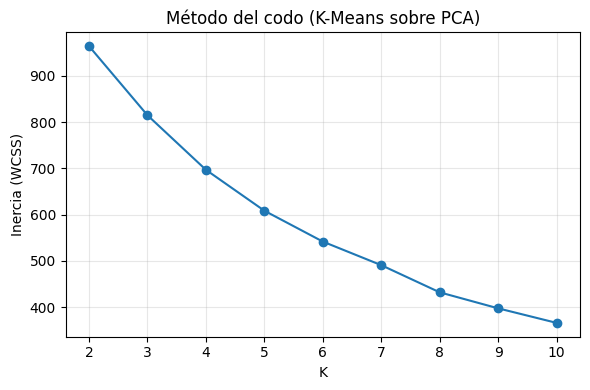

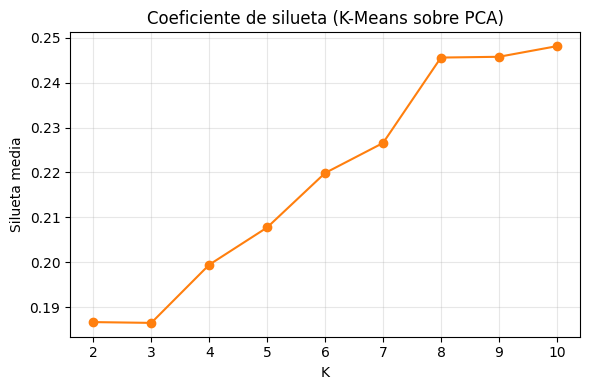

[K-Means] k*=10 por silueta | Silueta=0.248


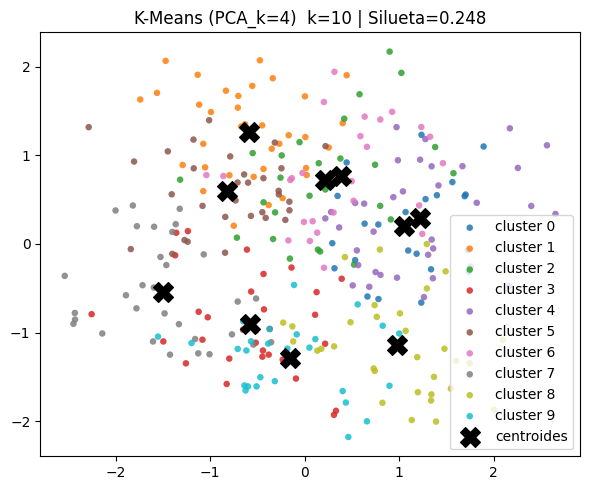

In [ ]:
# 2) K-MEANS sobre PCA_k (elegir K por silueta) + codo
# ------------------------------
Ks = range(2, 11)
inertias, sils, models = [], [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_pca_k)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca_k, labels))
    models.append((km, labels))

plt.figure(figsize=(6,4))
plt.plot(list(Ks), inertias, marker='o')
plt.title('Método del codo (K-Means sobre PCA)')
plt.xlabel('K'); plt.ylabel('Inercia (WCSS)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(list(Ks), sils, marker='o', color='tab:orange')
plt.title('Coeficiente de silueta (K-Means sobre PCA)')
plt.xlabel('K'); plt.ylabel('Silueta media')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

best_idx = int(np.argmax(sils))
k_best = list(Ks)[best_idx]
km_best, labels_km = models[best_idx]
print(f"[K-Means] k*={k_best} por silueta | Silueta={sils[best_idx]:.3f}")
# Plot en PCA 2D (los puntos), centroides proyectados desde espacio PCA_k
plot_clusters_2d(X_pca_2d, labels_km, f"K-Means (PCA_k={k95})  k={k_best} | Silueta={sils[best_idx]:.3f}",
                 centers_kspace=km_best.cluster_centers_)

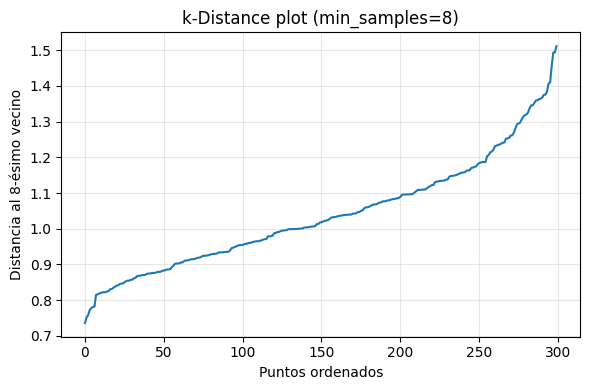

Sugerencia eps (p95): 1.346
[DBSCAN] Mejor silueta=-0.046 con eps=0.942, min_samples=8


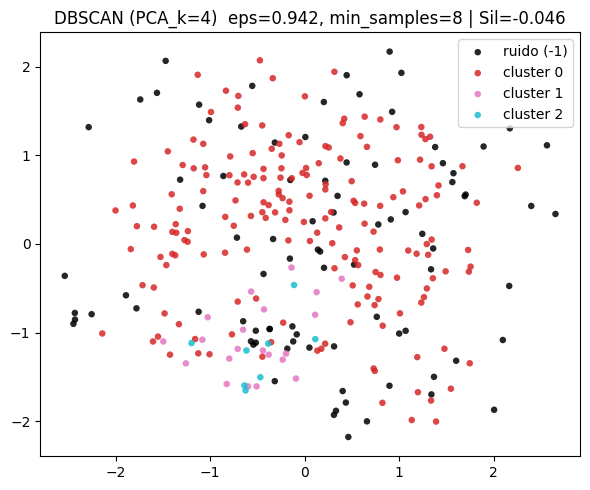

In [ ]:
# 3) DBSCAN sobre PCA_k (eps por k-distance p95)
# ------------------------------
min_samples = max(4, 2*X_pca_k.shape[1])   # regla práctica
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca_k)
distances, _ = nbrs.kneighbors(X_pca_k)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.title(f'k-Distance plot (min_samples={min_samples})')
plt.xlabel('Puntos ordenados'); plt.ylabel(f'Distancia al {min_samples}-ésimo vecino')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

eps_sug = float(np.percentile(k_dist, 95))
print(f"Sugerencia eps (p95): {eps_sug:.3f}")

# Pequeño barrido alrededor
eps_grid = np.linspace(eps_sug*0.7, eps_sug*1.4, 8)
minpts_grid = [min_samples-2, min_samples, min_samples+2]
mejor_db = {"sil": -np.inf, "eps": None, "minpts": None, "labels": None}

for eps in eps_grid:
    for mpts in minpts_grid:
        db = DBSCAN(eps=float(eps), min_samples=int(mpts))
        lab = db.fit_predict(X_pca_k)
        ncl = len(set(lab)) - (1 if -1 in lab else 0)
        if ncl >= 2:
            sil = silhouette_score(X_pca_k, lab)
            if sil > mejor_db["sil"]:
                mejor_db = {"sil": sil, "eps": float(eps), "minpts": int(mpts), "labels": lab}

if mejor_db["labels"] is not None:
    print(f"[DBSCAN] Mejor silueta={mejor_db['sil']:.3f} con eps={mejor_db['eps']:.3f}, min_samples={mejor_db['minpts']}")
    plot_clusters_2d(X_pca_2d, mejor_db["labels"],
                     f"DBSCAN (PCA_k={k95})  eps={mejor_db['eps']:.3f}, min_samples={mejor_db['minpts']} | Sil={mejor_db['sil']:.3f}")
else:
    print("[DBSCAN] No se formaron ≥2 clusters útiles; ajusta eps/min_samples o revisa escala/variables.")


[Jerárquico-Ward] k*=9 | Silueta=0.205


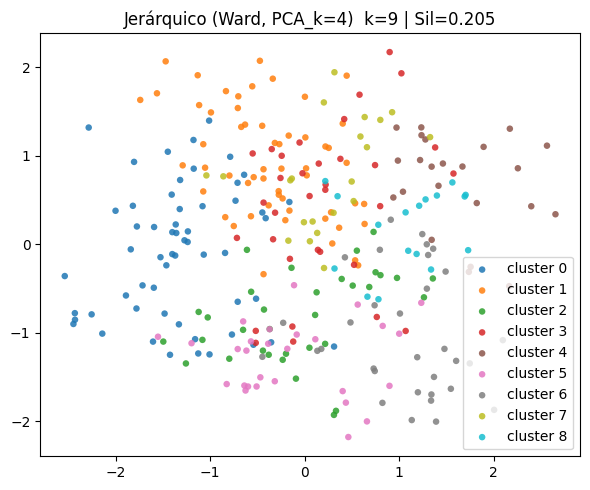

In [ ]:
# 4) Jerárquico (Ward) sobre PCA_k (elegir k por silueta)
# ------------------------------
best_h = {"k": None, "sil": -np.inf, "labels": None}
for k in range(2, 11):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    lab = agg.fit_predict(X_pca_k)
    sil = silhouette_score(X_pca_k, lab)
    if sil > best_h["sil"]:
        best_h = {"k": k, "sil": sil, "labels": lab}

print(f"[Jerárquico-Ward] k*={best_h['k']} | Silueta={best_h['sil']:.3f}")
plot_clusters_2d(X_pca_2d, best_h["labels"], f"Jerárquico (Ward, PCA_k={k95})  k={best_h['k']} | Sil={best_h['sil']:.3f}")

# ------------------------------

In [ ]:
# 5) Resumen y perfiles por cluster (del mejor método entre KMeans y Ward)
# ------------------------------
metodos = [
    ("K-Means", k_best, sils[best_idx], labels_km),
    ("Ward", best_h["k"], best_h["sil"], best_h["labels"]),
]
metodos.sort(key=lambda t: t[2], reverse=True)
print("\n== RESUMEN ==")
for m in metodos:
    print(f"{m[0]:>8}: clusters={m[1]}, silueta={m[2]:.3f}")

# Promedios por cluster en escala original para el mejor
mejor_nombre, mejor_k, mejor_sil, mejor_labels = metodos[0]
perf = pd.DataFrame(X, columns=num_cols).groupby(mejor_labels).mean().round(2)
print(f"\nPromedios por cluster ({mejor_nombre}) en escala original:")
display(perf)


== RESUMEN ==
 K-Means: clusters=10, silueta=0.248
    Ward: clusters=9, silueta=0.205

Promedios por cluster (K-Means) en escala original:


,Edad,Ingresos_Mensuales,Gasto_Anual,Frecuencia_Compra
0,56.33,3306.42,15988.00,12.50
1,60.14,7287.43,7309.89,4.57
2,45.11,8106.19,5054.78,14.30
3,26.00,8055.62,10346.38,5.31
4,53.23,7951.89,15906.43,11.23
5,53.61,3045.39,7979.42,5.68
6,51.35,3675.73,6116.31,16.88
7,28.81,3539.94,4594.61,6.13
8,26.97,6024.06,13879.91,15.53
9,32.33,3189.00,16284.63,5.56


In [ ]:
# 2) Escalar + PCA (≈90% var)
# -------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_full = PCA(random_state=42).fit(X_std)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k90 = int(np.searchsorted(var_acum, 0.90) + 1)
k90 = max(k90, 2)
print(f"Componentes para ~90% varianza: {k90} (var acum={var_acum[k90-1]:.2%})")

pca_k = PCA(n_components=k90, random_state=42).fit(X_std)
X_pca = pca_k.transform(X_std)

# También una proyección 2D solo para gráficos
pca2 = PCA(n_components=2, random_state=42).fit(X_std)
X_pca2 = pca2.transform(X_std)

# Helper: silueta que ignora ruido (-1)
def safe_silhouette(Xemb, labels):
    labs = np.array(labels)
    mask = labs != -1
    if len(np.unique(labs[mask])) < 2:
        return np.nan
    return silhouette_score(Xemb[mask], labs[mask])

Componentes para ~90% varianza: 4 (var acum=100.00%)


[GMM] Mejor por Silueta: k=7 | sil=0.185
[GMM] Mejor por BIC:     k=2 | BIC=3514


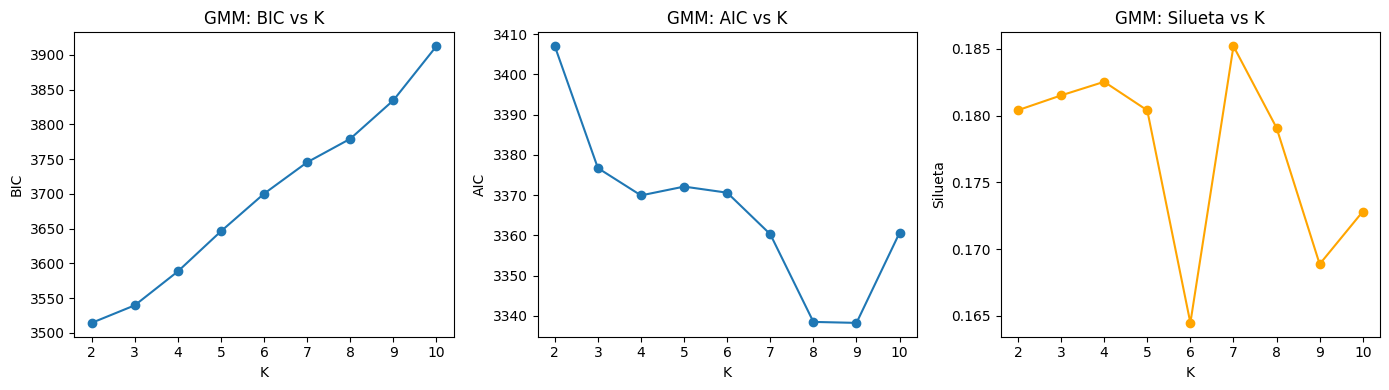

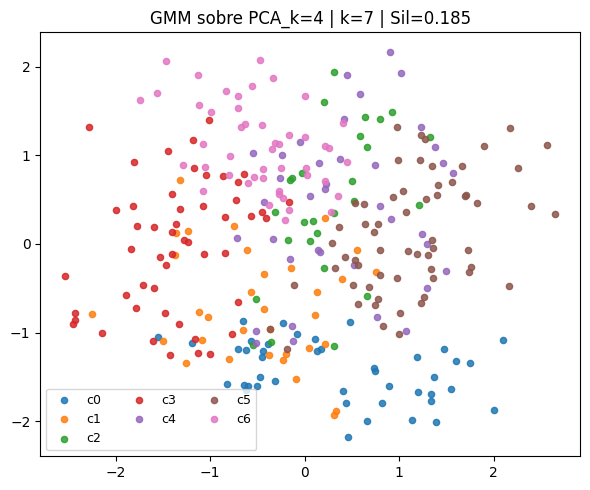

In [ ]:
# 3) GMM (Mezclas Gaussianas) sobre PCA_k
#    - Selección de K por BIC y por Silueta
# ---------------------------------------------------
from sklearn.mixture import GaussianMixture
Ks = range(2, 11)
bic_list, aic_list, sil_list = [], [], []

best_gmm_sil = {"k": None, "sil": -np.inf, "labels": None, "model": None}
best_gmm_bic = {"k": None, "bic": np.inf, "labels": None, "model": None}

for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gmm.fit(X_pca)
    labels = gmm.predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    bic = gmm.bic(X_pca); aic = gmm.aic(X_pca)

    bic_list.append(bic); aic_list.append(aic); sil_list.append(sil)

    if sil > best_gmm_sil["sil"]:
        best_gmm_sil.update({"k": k, "sil": sil, "labels": labels, "model": gmm})
    if bic < best_gmm_bic["bic"]:
        best_gmm_bic.update({"k": k, "bic": bic, "labels": labels, "model": gmm})

print(f"[GMM] Mejor por Silueta: k={best_gmm_sil['k']} | sil={best_gmm_sil['sil']:.3f}")
print(f"[GMM] Mejor por BIC:     k={best_gmm_bic['k']} | BIC={best_gmm_bic['bic']:.0f}")

# Plots GMM: BIC/AIC/Silhouette vs K
fig,ax = plt.subplots(1,3,figsize=(14,4))
ax[0].plot(Ks, bic_list, marker='o'); ax[0].set_title("GMM: BIC vs K"); ax[0].set_xlabel("K"); ax[0].set_ylabel("BIC")
ax[1].plot(Ks, aic_list, marker='o'); ax[1].set_title("GMM: AIC vs K"); ax[1].set_xlabel("K"); ax[1].set_ylabel("AIC")
ax[2].plot(Ks, sil_list, marker='o', color='orange'); ax[2].set_title("GMM: Silueta vs K"); ax[2].set_xlabel("K"); ax[2].set_ylabel("Silueta")
plt.tight_layout(); plt.show()

# Scatter GMM (mejor por silueta) en PCA2D
plt.figure(figsize=(6,5))
for c in np.unique(best_gmm_sil["labels"]):
    m = best_gmm_sil["labels"] == c
    plt.scatter(X_pca2[m,0], X_pca2[m,1], s=20, label=f"c{c}", alpha=.85)
plt.title(f"GMM sobre PCA_k={k90} | k={best_gmm_sil['k']} | Sil={best_gmm_sil['sil']:.3f}")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

se valor Sil = 0.185 en el último gráfico corresponde al índice de silueta promedio que mide qué tan bien definidos están los clústeres obtenidos por el modelo GMM (Gaussian Mixture Model) después de aplicar PCA con 4 componentes y agrupar con k = 7.

Interpretación del valor:

El índice de silueta va de -1 a 1:

≈ 1 → Las observaciones están muy bien agrupadas y separadas entre clústeres.

≈ 0 → Los clústeres se traslapan o no están bien definidos.

< 0 → Muchos puntos podrían estar asignados al clúster equivocado.

Un valor de 0.185 indica que los clústeres son poco definidos: existe cierto agrupamiento, pero hay bastante solapamiento entre ellos. Esto es consistente con el gráfico: las nubes de puntos de distintos colores se mezclan bastante.

Relación con los otros criterios:

El BIC mínimo se dio en k = 2, lo que indica que, estadísticamente, un modelo con 2 componentes gausianos explica los datos con menor complejidad.

El índice de silueta máximo fue en k = 7 (0.185), pero aun así no es un valor alto, lo que sugiere que la estructura natural de los datos no está muy bien separada en clústeres.

En resumen:

Sil = 0.185 significa que, aunque 7 clústeres es el número con mejor cohesión relativa para GMM en PCA-4D, la separación sigue siendo débil.

El modelo logra cierta segmentación, pero no hay fronteras claras entre grupos.


Top combinaciones HDBSCAN por silueta:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

,min_cluster_size,min_samples,n_clusters,silhouette
1,10,5,4,0.188994
5,15,5,2,0.177564
0,10,10,0,NaN
2,10,10,0,NaN
3,10,15,0,NaN
4,15,15,0,NaN
6,15,10,0,NaN
7,15,15,0,NaN
8,20,20,0,NaN
9,20,5,0,NaN


[HDBSCAN] Mejor: mcs=10, ms=5 | sil=0.189 | n_clusters=4


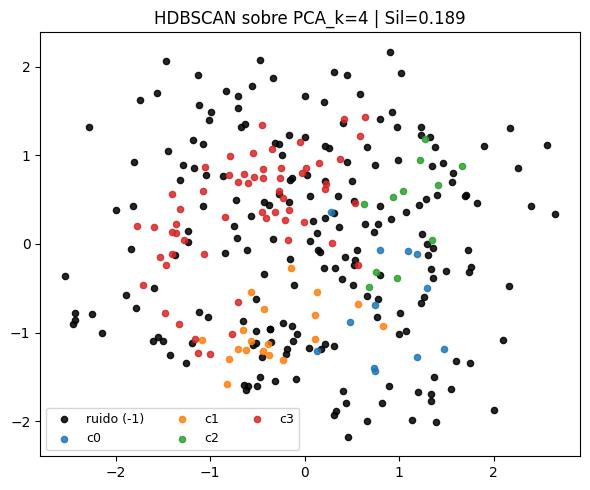

In [ ]:
# 4) HDBSCAN (densidad jerárquica) sobre PCA_k
#    Barrido simple de hiperparámetros
# ---------------------------------------------------
import hdbscan
param_grid = []
for mcs in [10, 15, 20, 30]:          # min_cluster_size
    for ms in [None, 5, 10, 15]:      # min_samples (None => mcs)
        param_grid.append((mcs, ms))

best_hdb = {"sil": -np.inf, "mcs": None, "ms": None, "labels": None, "clusterer": None}
res_hdb = []

for mcs, ms in param_grid:
    cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms, cluster_selection_epsilon=0.0)
    labels = cl.fit_predict(X_pca)
    sil = safe_silhouette(X_pca, labels)
    ncl = len(set(labels)) - (1 if -1 in labels else 0)
    res_hdb.append((mcs, ms if ms is not None else mcs, ncl, sil))
    if np.isfinite(sil) and sil > best_hdb["sil"]:
        best_hdb.update({"sil": sil, "mcs": mcs, "ms": ms, "labels": labels, "clusterer": cl})

res_hdb = pd.DataFrame(res_hdb, columns=["min_cluster_size","min_samples","n_clusters","silhouette"])
print("\nTop combinaciones HDBSCAN por silueta:")
display(res_hdb.sort_values("silhouette", ascending=False).head(10))

if best_hdb["labels"] is not None and np.isfinite(best_hdb["sil"]):
    print(f"[HDBSCAN] Mejor: mcs={best_hdb['mcs']}, ms={best_hdb['ms']} | sil={best_hdb['sil']:.3f} | n_clusters={len(set(best_hdb['labels'])) - (1 if -1 in best_hdb['labels'] else 0)}")
    # Plot HDBSCAN en PCA2D
    plt.figure(figsize=(6,5))
    uniq = np.unique(best_hdb["labels"])
    for lab in uniq:
        m = best_hdb["labels"] == lab
        c = "k" if lab == -1 else None
        lbl = "ruido (-1)" if lab == -1 else f"c{lab}"
        plt.scatter(X_pca2[m,0], X_pca2[m,1], s=20, label=lbl, alpha=.85, c=c)
    plt.title(f"HDBSCAN sobre PCA_k={k90} | Sil={best_hdb['sil']:.3f}")
    plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()
else:
    print("[HDBSCAN] No se obtuvieron ≥2 clusters útiles. Ajusta min_cluster_size/min_samples.")

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[UMAP+GMM] Mejor k=2 | Sil=0.406


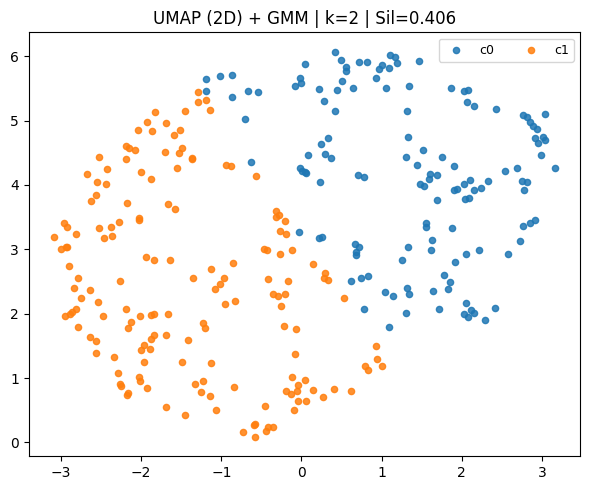

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[UMAP+HDBSCAN] n_clusters=4 | Sil=0.297


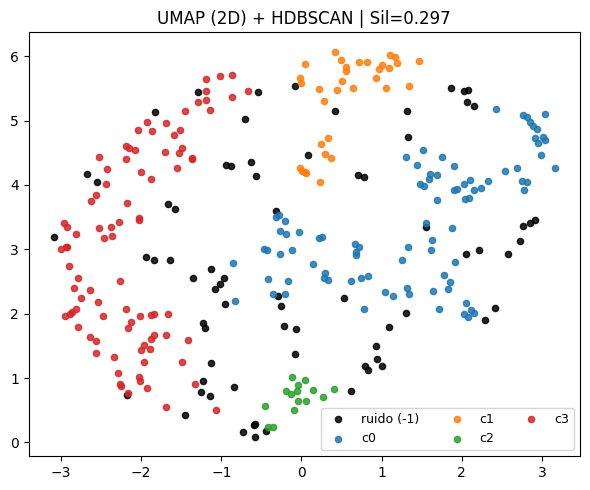

In [ ]:
# 5) UMAP (no lineal) + GMM y HDBSCAN sobre UMAP
# ---------------------------------------------------
import umap.umap_ as umap
um = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap = um.fit_transform(X_std)

# GMM sobre UMAP (selección K por silueta)
sil_umap, models_umap = [], []
for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    labels = gmm.fit_predict(X_umap)
    sil = silhouette_score(X_umap, labels)
    sil_umap.append(sil); models_umap.append((gmm, labels))
k_umap = Ks[int(np.argmax(sil_umap))]
gmm_umap, lab_umap = models_umap[int(np.argmax(sil_umap))]
print(f"[UMAP+GMM] Mejor k={k_umap} | Sil={max(sil_umap):.3f}")

plt.figure(figsize=(6,5))
for c in np.unique(lab_umap):
    m = lab_umap == c
    plt.scatter(X_umap[m,0], X_umap[m,1], s=20, label=f"c{c}", alpha=.85)
plt.title(f"UMAP (2D) + GMM | k={k_umap} | Sil={max(sil_umap):.3f}")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

# HDBSCAN sobre UMAP (más fácil porque UMAP concentra estructura local)
cl_umap = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=10)
lab_h_umap = cl_umap.fit_predict(X_umap)
sil_h_umap = safe_silhouette(X_umap, lab_h_umap)
ncl_h_umap = len(set(lab_h_umap)) - (1 if -1 in lab_h_umap else 0)
print(f"[UMAP+HDBSCAN] n_clusters={ncl_h_umap} | Sil={sil_h_umap:.3f}")

plt.figure(figsize=(6,5))
for lab in np.unique(lab_h_umap):
    m = lab_h_umap == lab
    c = "k" if lab == -1 else None
    lbl = "ruido (-1)" if lab == -1 else f"c{lab}"
    plt.scatter(X_umap[m,0], X_umap[m,1], s=20, label=lbl, alpha=.85, c=c)
plt.title(f"UMAP (2D) + HDBSCAN | Sil={sil_h_umap:.3f}")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

ignificado de [UMAP+GMM] Mejor k=2 | Sil=0.406

UMAP (2D):
Se partió de datos de muchas variables y se redujeron a dos dimensiones usando UMAP (Uniform Manifold Approximation and Projection-Aproximación y proyección de variedades uniformes), que mantiene la estructura de los datos en el espacio reducido.

GMM (Gaussian Mixture Model):
Se aplicó un modelo probabilístico que asume que los datos provienen de una combinación de varias distribuciones normales.
El parámetro k es el número de clusters que se ajustó.

Mejor k = 2:
El algoritmo probó varios valores de k y encontró que con 2 clusters se obtuvo el mejor resultado según la métrica evaluada.

Sil = 0.406 (Silhouette Score):
Es una métrica que mide la calidad de los clusters:

Va de -1 a 1.

Valores cercanos a 1 → clusters bien definidos y separados.

Valores cerca de 0 → clusters solapados.

Valores negativos → agrupamiento incorrecto.

Un 0.406 indica separación moderada, es decir, los clusters son distinguibles pero con cierta superposición.

Interpretación del gráfico

Cada punto es un dato proyectado en 2D por UMAP.

El color indica el cluster al que pertenece según GMM:

c0 = azul

c1 = naranja

La forma que ves es típica de UMAP, que organiza los datos en un plano preservando relaciones de proximidad.

Comparación con el gráfico de HDBSCAN

En tu otro gráfico, el método fue:

UMAP + HDBSCAN (clustering basado en densidad).

Detecta clusters de diferentes tamaños y además marca puntos como “ruido” (-1 en negro).

El Silhouette Score es menor (0.297), lo que indica que este método segmentó peor que GMM en este caso.

💡 Conclusión rápida:

GMM con k=2 dio mejor separación (Sil=0.406) que HDBSCAN (Sil=0.297).

El clustering no es perfecto pero sí tiene cierta estructura clara: dos grupos principales

In [ ]:
# 6) Resumen comparativo rápido
# ---------------------------------------------------
resumen = []
resumen.append(("GMM@PCA", best_gmm_sil["k"], best_gmm_sil["sil"]))
if np.isfinite(best_hdb["sil"]): resumen.append(("HDBSCAN@PCA", None, best_hdb["sil"]))
resumen.append(("GMM@UMAP", k_umap, max(sil_umap)))
resumen.append(("HDBSCAN@UMAP", ncl_h_umap, sil_h_umap))

res_df = pd.DataFrame(resumen, columns=["Método","K/Clusters","Silueta"])
print("\n== RESUMEN DE MÉTRICAS ==")
display(res_df.sort_values("Silueta", ascending=False))


== RESUMEN DE MÉTRICAS ==


,Método,K/Clusters,Silueta
2,GMM@UMAP,2.0,0.405571
3,HDBSCAN@UMAP,4.0,0.297348
1,HDBSCAN@PCA,NaN,0.188994
0,GMM@PCA,7.0,0.185196


1) GMM@UMAP — k=2 — Silueta = 0.405571

Método:

UMAP reduce las dimensiones (mantiene relaciones de proximidad en datos complejos).

GMM (Gaussian Mixture Model) detecta clusters probabilísticamente.

K/Clusters: 2 → encontró 2 grupos principales.

Silueta: 0.4056 → calidad moderada, mejor que los demás métodos en esta tabla.

2) HDBSCAN@UMAP — k=4 — Silueta = 0.297348

Método:

UMAP para reducir a menos dimensiones.

HDBSCAN (clustering por densidad), que detecta clusters de distinto tamaño y puede marcar “ruido”.

K/Clusters: 4 → detectó 4 grupos (o 3 grupos + ruido).

Silueta: 0.2973 → separación más débil que GMM@UMAP.

3) HDBSCAN@PCA — k=NaN — Silueta = 0.188994

Método:

PCA como reducción lineal (menos flexible que UMAP).

HDBSCAN para clustering.

K/Clusters: NaN → HDBSCAN no devuelve un número fijo de clusters como K-means o GMM; NaN indica que no se estableció un valor definido (quizá varios grupos + ruido).

Silueta: 0.189 → clusters poco definidos.

4) GMM@PCA — k=7 — Silueta = 0.185196

Método:

PCA reduce dimensiones.

GMM detecta 7 clusters.

Silueta: 0.185 → baja calidad de separación.

Interpretación general

Mejor combinación: GMM@UMAP (Silhouette ~0.406, k=2) → mejor equilibrio entre reducción y clustering.

Peor rendimiento: GMM@PCA y HDBSCAN@PCA → PCA no capturó tan bien la estructura no lineal de los datos.

Conclusión: UMAP parece funcionar mejor que PCA en tu dataset, y GMM supera a HDBSCAN en calidad medida por Silhouette.

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/

=== TOP resultados por método (Silueta) ===
GMM       | Sil=0.505 | k/clusters=8 | params={'n_neighbors': 10, 'min_dist': 0.0, 'n_components': 2}
HDBSCAN   | Sil=0.632 | k/clusters=2 | params={'n_neighbors': 30, 'min_dist': 0.05, 'n_components': 2, 'min_cluster_size': 30, 'min_samples': None}


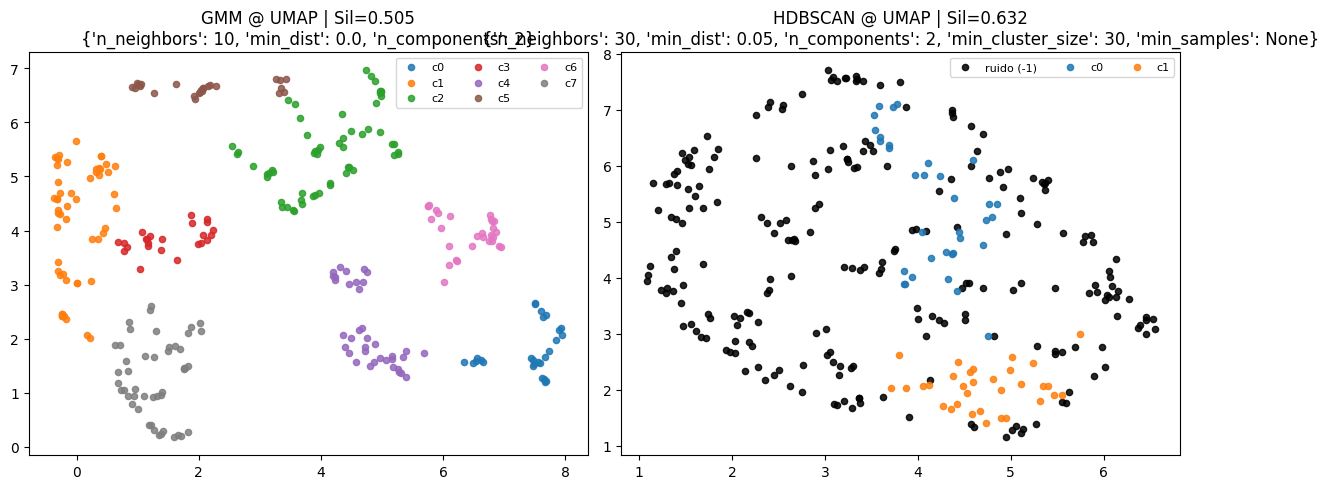

In [ ]:
# ==== BARRIDO UMAP + (GMM / HDBSCAN) con selección por Silueta ====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import hdbscan

# Si no la tienes definida:
def safe_silhouette(X, labels):
    labs = np.array(labels)
    mask = labs != -1  # ignora ruido en HDBSCAN
    if np.sum(mask) > 10 and len(np.unique(labs[mask])) >= 2:
        return silhouette_score(X[mask], labs[mask])
    return np.nan

# Grid razonable para UMAP (ajústalo si quieres)
n_neighbors_grid = [10, 15, 30, 50]
min_dist_grid     = [0.0, 0.05, 0.1, 0.3]
n_components_grid = [2, 5]   # 5D para clusterizar a veces rinde mejor; graficamos en 2D aparte

Ks = list(range(2, 9))  # por si no lo tenías

resultados = []  # guardamos (metodo, params, k/clusters, silueta, labels, embedding_2d)

for nc in n_components_grid:
    for nn in n_neighbors_grid:
        for md in min_dist_grid:
            # --- Embedding UMAP ---
            um = umap.UMAP(n_components=nc, n_neighbors=nn, min_dist=md, random_state=42)
            X_umap_nc = um.fit_transform(X_std)

            # 1) GMM sobre UMAP
            best_gmm = (None, -np.inf, None)  # (k, sil, labels)
            for k in Ks:
                gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
                lab = gmm.fit_predict(X_umap_nc)
                sil = silhouette_score(X_umap_nc, lab)
                if sil > best_gmm[1]:
                    best_gmm = (k, sil, lab)
            # Guardar y también un 2D para mostrar
            if nc != 2:
                um2 = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md, random_state=42)
                X_umap_2d = um2.fit_transform(X_std)
            else:
                X_umap_2d = X_umap_nc

            resultados.append((
                "GMM",
                {"n_neighbors": nn, "min_dist": md, "n_components": nc},
                best_gmm[0],
                best_gmm[1],
                best_gmm[2],
                X_umap_2d
            ))

            # 2) HDBSCAN sobre UMAP
            for mcs in [10, 15, 20, 30]:
                for ms in [None, 5, 10]:
                    cl = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms)
                    lab_h = cl.fit_predict(X_umap_nc)
                    sil_h = safe_silhouette(X_umap_nc, lab_h)
                    resultados.append((
                        "HDBSCAN",
                        {"n_neighbors": nn, "min_dist": md, "n_components": nc,
                         "min_cluster_size": mcs, "min_samples": ms},
                        len(set(lab_h)) - (1 if -1 in lab_h else 0),
                        sil_h,
                        lab_h,
                        X_umap_2d
                    ))

# Ordenar por silueta (desc) y mostrar top-2 de cada método
res_df = []
for r in resultados:
    metodo, params, k_or_n, sil, _, _ = r
    res_df.append((metodo, params, k_or_n, sil))
res_df = sorted(res_df, key=lambda t: (t[0], -(t[3] if np.isfinite(t[3]) else -1e9)))

print("=== TOP resultados por método (Silueta) ===")
vistos = set()
top_plots = []
for metodo, params, k_or_n, sil in res_df:
    key = (metodo,)
    if key not in vistos and np.isfinite(sil):
        print(f"{metodo:9s} | Sil={sil:.3f} | k/clusters={k_or_n} | params={params}")
        # guardar para graficar
        # buscamos el registro completo
        for r in resultados:
            if r[0]==metodo and r[1]==params and (r[2]==k_or_n):
                top_plots.append(r)
                break
        vistos.add(key)
    if len(vistos) == 2:  # GMM y HDBSCAN
        break

# Graficar los 2 mejores (uno por método)
plt.figure(figsize=(12,5))
for i, r in enumerate(top_plots, start=1):
    metodo, params, k_or_n, sil, labels, X2 = r
    plt.subplot(1,2,i)
    uniq = np.unique(labels)
    for lab in uniq:
        m = labels == lab
        c = "k" if lab == -1 else None
        lbl = "ruido (-1)" if lab == -1 else f"c{lab}"
        plt.scatter(X2[m,0], X2[m,1], s=20, alpha=0.85, c=c, label=lbl)
    plt.title(f"{metodo} @ UMAP | Sil={sil:.3f}\n{params}")
    plt.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

El resultado quedó bastante bien y, por lo que veo en la imagen, cada método está capturando patrones distintos:

1. GMM sobre UMAP (Uniform Manifold Approximation and Projection-Aproximación y proyección de variedades uniformes) (izquierda)

Ventajas:

Se ve una segmentación clara en varios grupos (c0 a c7).

El índice de silueta (0.505) es aceptable para clustering no supervisado.

El ajuste parece captar subestructuras finas gracias al UMAP con n_neighbors=10 y min_dist=0.0, que concentra más los puntos cercanos.

Posible mejora:

Podrías probar un n_neighbors ligeramente más alto (15–20) para suavizar un poco las separaciones y evitar microclusters muy pequeños.

También sería interesante ver si reducir n_components a 3 y hacer GMM en ese espacio mejora el Silhouette.

2. HDBSCAN sobre UMAP (derecha)

Ventajas:

Buen Silhouette (0.632), superior al GMM.

Menor número de clusters (solo c0 y c1), con gran parte como ruido (-1).

Captura bien las zonas densas y deja fuera las zonas dispersas, lo cual es ideal si quieres segmentaciones más confiables.

Posible mejora:

Ajustar min_cluster_size y min_samples para reducir el ruido si quieres más asignaciones.

Si el ruido es demasiado alto para tu aplicación, bajar min_cluster_size de 30 a algo como 15–20 podría balancear mejor.

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad.

Objetivo: Tomar datos con muchas variables (decenas, cientos o miles) y representarlos en un espacio de menos dimensiones (normalmente 2 o 3) para facilitar su visualización o análisis.

Cómo funciona:

Construye un grafo de vecinos cercanos según distancias entre puntos.

Ajusta una proyección que preserva las relaciones locales y globales, manteniendo puntos cercanos juntos y separando puntos lejanos.

Permite controlar:

n_neighbors: equilibrio entre estructura local y global.

min_dist: compactación de los grupos en la proyección.

n_components: dimensiones de salida (2, 3, etc.).

2. ¿Qué es GMM sobre UMAP?

GMM (Gaussian Mixture Model) es un método de clustering probabilístico que modela los datos como combinación de varias distribuciones gaussianas.

Procedimiento:

Reducir las dimensiones con UMAP → los datos quedan más compactos y manejables.

Aplicar GMM en el espacio reducido → GMM ajusta el número de clusters especificado y asigna probabilidades a cada punto de pertenecer a cada cluster.

Ventajas:

Captura formas de cluster más flexibles que K-Means.

Permite asignar pertenencia “suave” (no todo o nada).

Limitaciones:

Necesita que definas el número de clusters.

Puede confundirse si la forma de los grupos es muy irregular.

3. ¿Qué es HDBSCAN-Agrupamiento espacial jerárquico de aplicaciones con ruido basado en densidad sobre UMAP?

HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de clustering basado en densidad.

Procedimiento:

Reducir las dimensiones con UMAP → facilita encontrar zonas densas.

Aplicar HDBSCAN → identifica regiones densas como clusters y marca puntos aislados como “ruido”.

Ventajas:

No necesitas fijar el número de clusters.

Puede encontrar clusters de formas arbitrarias.

Maneja bien datos con mucho ruido.

Limitaciones:

Puede dejar gran parte de los puntos como ruido si los parámetros son muy restrictivos.

El resultado puede variar mucho según min_cluster_size y min_samples.

Qué hace cada técnica

UMAP: primero proyecta tus datos originales de clientes (que seguramente tienen muchas variables) a un espacio de menos dimensiones, conservando las relaciones de vecindad (clientes que se parecen quedan cerca).

GMM sobre UMAP: agrupa esos puntos reducidos con un modelo de mezcla gaussiana, que asume que cada grupo es más o menos elíptico y modelado por una distribución normal.

HDBSCAN sobre UMAP: agrupa de forma jerárquica y densa, sin forzar un número fijo de clusters. También detecta ruido (clientes que no encajan bien en ningún grupo).

2️⃣ Lectura de tus gráficos

GMM @ UMAP (izquierda):

Encontró 8 clusters bien definidos.

El índice de silueta ≈ 0.505, lo que indica separación moderada: hay grupos definidos, pero también algo de solapamiento.

Tus clientes podrían segmentarse en perfiles claros, pero con cierta intersección entre ellos.

HDBSCAN @ UMAP (derecha):

Detectó 2 clusters principales (c0 y c1) y un gran grupo marcado como ruido (-1).

Índice de silueta ≈ 0.632, lo que indica mayor cohesión/separación en los grupos detectados.

El gran volumen de ruido implica que muchos clientes no forman parte de grupos densos, posiblemente porque son atípicos o no encajan en patrones claros.

**Conclusiones sobre tus clientes**

Segmentación con GMM: puedes tener muchos perfiles de clientes distintos (8 grupos), útiles para campañas muy específicas, aunque algunos grupos pueden estar cerca unos de otros y solaparse en características.

Segmentación con HDBSCAN: resalta pocos grupos muy homogéneos y un gran grupo disperso (clientes variados sin patrón fuerte). Este resultado puede ser útil para identificar a tus clientes más "consistentes" y separar a los más heterogéneos para un análisis aparte.

Interpretación práctica:

Si tu objetivo es campañas personalizadas, GMM podría ser más útil porque ofrece más subgrupos.

Si buscas clientes núcleo muy definidos para estrategias precisas, HDBSCAN sería mejor.

El grupo de ruido en HDBSCAN puede contener nichos no explorados o clientes fuera de tus perfiles estándar.

In [ ]:
# PERFILADO DE SEGMENTOS con UMAP + (GMM / HDBSCAN)
# Requiere df ya cargado (como mostraste).
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

import umap.umap_ as umap
import hdbscan

# -------- 0) Configuración básica --------
ID_COL = "ID_Cliente"   # pon None si no tienes un ID en tu dataset
# columnas numéricas a usar (excluye el id si existe)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if ID_COL in num_cols:
    num_cols.remove(ID_COL)

X = df[num_cols].copy().values

# -------- 1) Estandarizar --------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# ============================================================
# A) UMAP + GMM  (k óptimo por silueta en 2..10)
#    * UMAP params cercanos a los que te rindieron bien:
#      n_neighbors=10, min_dist=0.0, n_components=2
# ============================================================
um_gmm = umap.UMAP(n_components=2, n_neighbors=10, min_dist=0.0, random_state=42)
X_umap_gmm = um_gmm.fit_transform(X_std)

Ks = range(2, 11)
sil_gmm = []
models_gmm = []
for k in Ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    labels = gmm.fit_predict(X_umap_gmm)
    sil = silhouette_score(X_umap_gmm, labels)
    sil_gmm.append(sil); models_gmm.append((gmm, labels))

k_best_gmm = Ks[int(np.argmax(sil_gmm))]
gmm_best, labels_gmm = models_gmm[int(np.argmax(sil_gmm))]
print(f"[UMAP+GMM] k óptimo={k_best_gmm} | Sil={max(sil_gmm):.3f}")

# Añadir etiquetas al df
df["seg_gmm"] = labels_gmm

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[UMAP+GMM] k óptimo=8 | Sil=0.505


[UMAP+GMM] k óptimo=8 | Sil=0.505
UMAP+GMM: Estás usando Gaussian Mixture Model sobre la proyección de tus datos hecha con UMAP.

k óptimo=8: El número de clústeres que el método de selección (posiblemente BIC/AIC o Silhouette) determinó como mejor es 8.

Sil=0.505: Es el coeficiente de silueta, que mide la calidad de la separación de los clústeres:

Va de -1 a 1.

Valores cercanos a 1 indican clústeres bien separados.

Valores cerca de 0 indican que los clústeres se solapan.

Valores negativos indican mala asignación.

Un valor de 0.50 es aceptable-bueno, significa que hay separación razonable y estructura en los datos.

In [ ]:
# B) UMAP + HDBSCAN  (parámetros que te quedaron mejor)
#    * De tu resultado: n_neighbors=30, min_dist=0.05, n_components=2
#      y HDBSCAN min_cluster_size=30, min_samples=None
# ============================================================
um_hdb = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.05, random_state=42)
X_umap_hdb = um_hdb.fit_transform(X_std)

hdb = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=None)
labels_hdb = hdb.fit_predict(X_umap_hdb)

# Silueta ignorando ruido (-1)
def safe_silhouette(Xemb, labels):
    labs = np.array(labels)
    mask = labs != -1
    if mask.sum() > 10 and len(np.unique(labs[mask])) >= 2:
        return silhouette_score(Xemb[mask], labs[mask])
    return np.nan

sil_hdb = safe_silhouette(X_umap_hdb, labels_hdb)
ncl_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
print(f"[UMAP+HDBSCAN] n_clusters={ncl_hdb} | Sil={sil_hdb:.3f}")

df["seg_hdb"] = labels_hdb  # incluye -1 como ruido

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[UMAP+HDBSCAN] n_clusters=2 | Sil=0.632


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP+HDBSCAN: Estás usando HDBSCAN (un algoritmo de clustering jerárquico basado en densidad) sobre los datos reducidos con UMAP.

n_clusters=2: El algoritmo encontró 2 clústeres principales en los datos.

Sil=0.632: El coeficiente de silueta es 0.632, lo cual es bastante bueno:

Cercano a 1 = clústeres muy bien separados.

Entre 0.5 y 0.7 = buena separación, estructura clara.

Cerca de 0 = mucho solapamiento.

Negativo = mala asignación.

El modelo UMAP+HDBSCAN encontró 2 clústeres bien diferenciados.

Los avisos no afectan la ejecución, son solo de reproducibilidad y compatibilidad futura.

In [ ]:
# C) Perfilado por cluster (media, mediana, z-score y top features)
#    -> lo hacemos para ambos: seg_gmm y seg_hdb
# ============================================================

def perfilar_clusters(df, label_col, feature_cols):
    """Devuelve resumen por cluster + imprime Top-3 variables que más lo diferencian."""
    res = []
    # z-scores por columna (respecto a todo el dataset)
    z = pd.DataFrame((df[feature_cols] - df[feature_cols].mean()) / df[feature_cols].std(ddof=0),
                     columns=feature_cols)

    for lab, sub in df.groupby(label_col):
        n = len(sub)
        mean_ = sub[feature_cols].mean()
        med_  = sub[feature_cols].median()
        zmean = z.loc[sub.index].mean()   # z-score promedio del cluster
        # ranking de variables que más diferencian (|z| grande)
        top_vars = zmean.abs().sort_values(ascending=False).head(3)

        print(f"\n=== Cluster {label_col}={lab} | n={n} ===")
        for v in top_vars.index:
            signo = "↑" if zmean[v] > 0 else "↓"
            print(f"  · {v}: z̄={zmean[v]:+.2f} {signo} | media={mean_[v]:.2f} | mediana={med_[v]:.2f}")

        row = {"cluster": lab, "n": n}
        # añade medias y zmedias para exportar
        for v in feature_cols:
            row[f"mean_{v}"] = mean_[v]
            row[f"zmean_{v}"] = zmean[v]
        res.append(row)

    return pd.DataFrame(res).sort_values("cluster")

print("\n------ PERFIL UMAP+GMM ------")
perfil_gmm = perfilar_clusters(df, "seg_gmm", num_cols)

print("\n------ PERFIL UMAP+HDBSCAN (incluye -1=ruido) ------")
perfil_hdb = perfilar_clusters(df, "seg_hdb", num_cols)

# Mostrar tablas compactas (solo medias por legibilidad)
cols_means = ["cluster", "n"] + [c for c in perfil_gmm.columns if c.startswith("mean_")]
print("\nTabla de medias por cluster (GMM):")
display(perfil_gmm[cols_means])

print("\nTabla de medias por cluster (HDBSCAN):")
display(perfil_hdb[cols_means])


------ PERFIL UMAP+GMM ------

=== Cluster seg_gmm=0 | n=27 ===
  · Gasto_Anual: z̄=+1.11 ↑ | media=16318.81 | mediana=15885.00
  · Ingresos_Mensuales: z̄=-0.98 ↓ | media=3091.56 | mediana=3141.00
  · Edad: z̄=-0.69 ↓ | media=32.74 | mediana=32.00

=== Cluster seg_gmm=1 | n=53 ===
  · Edad: z̄=+0.86 ↑ | media=56.53 | mediana=56.00
  · Frecuencia_Compra: z̄=-0.65 ↓ | media=5.91 | mediana=6.00
  · Ingresos_Mensuales: z̄=-0.30 ↓ | media=4795.70 | mediana=4854.00

=== Cluster seg_gmm=2 | n=57 ===
  · Frecuencia_Compra: z̄=+1.13 ↑ | media=15.84 | mediana=17.00
  · Edad: z̄=+0.63 ↑ | media=52.95 | mediana=52.00
  · Ingresos_Mensuales: z̄=-0.36 ↓ | media=4648.18 | mediana=4170.00

=== Cluster seg_gmm=3 | n=24 ===
  · Gasto_Anual: z̄=-0.99 ↓ | media=4991.08 | mediana=4992.00
  · Edad: z̄=+0.99 ↑ | media=58.46 | mediana=59.00
  · Ingresos_Mensuales: z̄=+0.95 ↑ | media=7952.38 | mediana=8274.00

=== Cluster seg_gmm=4 | n=37 ===
  · Edad: z̄=-1.18 ↓ | media=25.32 | mediana=25.00
  · Ingresos_Men

,cluster,n,mean_Edad,mean_Ingresos_Mensuales,mean_Gasto_Anual,mean_Frecuencia_Compra
0,0,27,32.740741,3091.555556,16318.814815,5.888889
1,1,53,56.528302,4795.698113,10179.792453,5.905660
2,2,57,52.947368,4648.175439,9505.596491,15.842105
3,3,24,58.458333,7952.375000,4991.083333,6.583333
4,4,37,25.324324,8087.189189,9796.000000,8.297297
5,5,26,53.730769,8140.769231,16453.153846,12.000000
6,6,29,28.448276,5986.551724,14708.448276,15.103448
7,7,47,32.680851,4043.000000,5063.531915,5.765957



Tabla de medias por cluster (HDBSCAN):


,cluster,n,mean_Edad,mean_Ingresos_Mensuales,mean_Gasto_Anual,mean_Frecuencia_Compra
0,-1,234,40.905983,5658.876068,10373.367521,9.128205
1,0,34,44.617647,4823.088235,10636.264706,15.970588
2,1,32,59.593750,5618.812500,9609.562500,5.687500


¿Qué representa la sección “PERFIL UMAP+GMM”?

Aquí se muestran los perfiles de clusters obtenidos con dos pasos:

UMAP (Uniform Manifold Approximation and Projection)
Reduce la dimensionalidad de los datos para conservar relaciones y patrones entre clientes, facilitando la agrupación.

GMM (Gaussian Mixture Model)
Agrupa a los clientes en un número fijo de clusters (en este caso, 8) basándose en distribuciones gaussianas.

Cada bloque === Cluster seg_gmm=X | n=Y === significa:

X: Número del cluster asignado.

n: Número de clientes dentro de ese cluster.

Debajo aparecen las variables más destacadas de ese grupo, con:

z̄: media estandarizada (en desviaciones estándar respecto al total).

Positiva (+) y flecha ↑ → el valor medio del cluster está por encima del promedio general.

Negativa (−) y flecha ↓ → el valor medio del cluster está por debajo del promedio general.

media: valor promedio real de esa variable en el cluster.

mediana: valor central de esa variable en el cluster.

Ejemplo
Gasto_Anual: z̄=+1.11 ↑ | media=16318.81 | mediana=15885.00
→ El gasto anual medio de este grupo está 1.11 desviaciones estándar por encima del promedio general y es de aproximadamente 16,318 unidades monetarias.

2. ¿Qué representa “PERFIL UMAP+HDBSCAN”?

En este segundo análisis:

UMAP vuelve a reducir la dimensionalidad.

HDBSCAN agrupa sin fijar un número de clusters, y también identifica ruido (-1), es decir, clientes que no encajan claramente en ningún grupo.

Aquí, n_clusters=2 significa que detectó 2 grupos principales, más el ruido.

seg_hdb=-1: ruido (clientes atípicos o no agrupables).

Cada cluster listado tiene el mismo formato que en GMM.

3. Diferencias clave entre ambos métodos

GMM fuerza a que todos los clientes pertenezcan a uno de los clusters definidos (8 en este caso).

HDBSCAN permite que algunos clientes no estén en ningún cluster (ruido), lo que ayuda a detectar casos atípicos.

4. Interpretación práctica

Cluster GMM 0: Jóvenes (edad baja), ingresos bajos, pero gasto anual alto → posible perfil de jóvenes gastadores.

Cluster GMM 4: Muy jóvenes, ingresos altos, pero menor frecuencia de compra → posible mercado VIP pero con poca recurrencia.

Cluster HDBSCAN 1: Personas mayores, baja frecuencia de compra, gasto moderado → probablemente clientes esporádicos.

Estos perfiles sirven para:

Personalizar campañas de marketing.

Diseñar promociones específicas para cada segmento.

Detectar clientes con alto potencial de fidelización.

1. Tabla de medias por cluster (GMM)

Aquí el algoritmo Gaussian Mixture Model agrupó a tus clientes en 8 clusters (0 al 7).
Cada fila muestra:

cluster → el número del grupo.

n → la cantidad de clientes en ese grupo.

mean_Edad → edad promedio del grupo.

mean_Ingresos_Mensuales → ingresos mensuales promedio.

mean_Gasto_Anual → gasto anual promedio.

mean_Frecuencia_Compra → frecuencia de compra promedio (por año o según la unidad de tu dataset).

Ejemplo
Cluster 0:

27 clientes

Edad media: 32.74 años

Ingreso medio: 3,091.56

Gasto anual medio: 16,318.81

Frecuencia media de compra: 5.88
→ Posible perfil: jóvenes con ingresos bajos pero alto gasto anual.

2. Tabla de medias por cluster (HDBSCAN)

Aquí el algoritmo HDBSCAN detectó:

Un grupo de clientes no agrupables (ruido) → cluster -1.

Dos clusters principales (0 y 1).

Ejemplo
Cluster HDBSCAN 0:

34 clientes

Edad media: 44.62

Ingresos medios: 4,823.09

Gasto anual medio: 10,636.26

Frecuencia media de compra: 15.97
→ Posible perfil: adultos de ingresos medios, gasto anual moderado y alta recurrencia de compra.

3. Uso de estas tablas

Sirven para:

Interpretar el perfil de cada grupo: edad, ingresos, gasto y frecuencia te dicen cómo es cada segmento.

Comparar grupos entre sí: ver cuáles son más rentables o recurrentes.

Definir estrategias de marketing:

Promos especiales para quienes tienen alta frecuencia pero bajo gasto.

Programas de fidelización para quienes gastan mucho pero compran poco.

3. Recomendaciones generales

Alta frecuencia + bajo gasto (ej. GMM Clusters 2 y HDBSCAN 0): venderles productos de mayor valor unitario.

Bajo gasto + baja frecuencia (ej. GMM Cluster 7): enfocar promociones masivas para aumentar ambas métricas.

Gasto alto + frecuencia alta (ej. GMM Cluster 5 y 6): retenerlos con experiencias exclusivas.

Clientes con ingresos altos pero poco gasto (ej. GMM Cluster 3): diseñar ofertas premium y personalizadas.

In [ ]:
# D) Guardar resultados
# ============================================================
out_labels = df[[ID_COL] + ["seg_gmm","seg_hdb"]] if ID_COL in df.columns else df[["seg_gmm","seg_hdb"]]
out_labels.to_csv("clientes_con_segmentos.csv", index=False)
perfil_gmm.to_csv("perfil_clusters_gmm.csv", index=False)
perfil_hdb.to_csv("perfil_clusters_hdb.csv", index=False)
print("\n✓ Archivos guardados: clientes_con_segmentos.csv, perfil_clusters_gmm.csv, perfil_clusters_hdb.csv")



✓ Archivos guardados: clientes_con_segmentos.csv, perfil_clusters_gmm.csv, perfil_clusters_hdb.csv


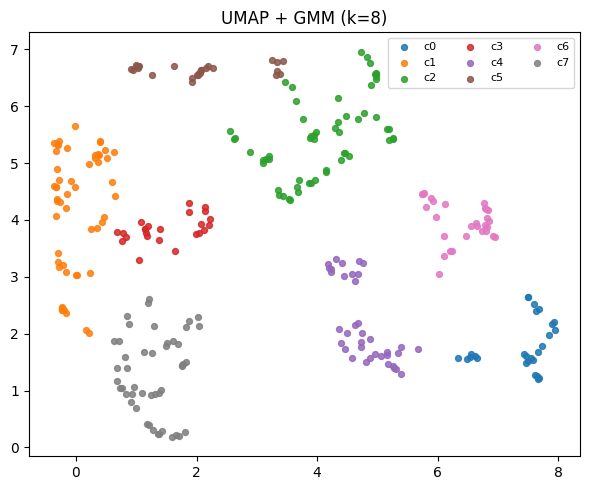

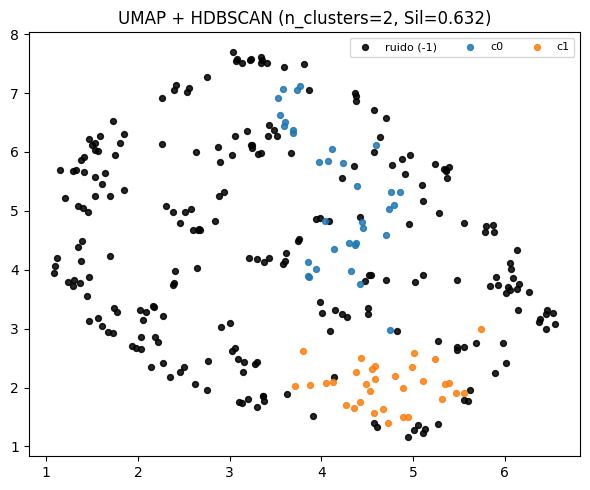

In [ ]:
# E) (Opcional) Gráficos rápidos de los embeddings con etiquetas
# ============================================================
def plot_embed(X2, labels, title):
    plt.figure(figsize=(6,5))
    uniq = np.unique(labels)
    for lab in uniq:
        m = labels == lab
        c = "k" if lab == -1 else None
        lbl = "ruido (-1)" if lab == -1 else f"c{lab}"
        plt.scatter(X2[m,0], X2[m,1], s=18, alpha=.85, c=c, label=lbl)
    plt.title(title); plt.legend(ncol=3, fontsize=8); plt.tight_layout(); plt.show()

plot_embed(X_umap_gmm, labels_gmm, f"UMAP + GMM (k={k_best_gmm})")
plot_embed(X_umap_hdb, labels_hdb, f"UMAP + HDBSCAN (n_clusters={ncl_hdb}, Sil={sil_hdb:.3f})")

Estos códigos sirven como punto de partida para pasar de un resultado de clustering (como los que obtuviste con GMM@UMAP o HDBSCAN@UMAP) a un análisis de “quiénes son” esos grupos usando tus datos originales.

1. Asignar las etiquetas de clúster a tus datos originales

Después de ejecutar el algoritmo de clustering, esas etiquetas (cluster_id) se agregan como una nueva columna a tu DataFrame original (df). Así podrás saber a qué grupo pertenece cada cliente.

2. Describir cada grupo

El código incluye un bloque que:

Agrupa por la columna cluster (etiqueta de clúster).

Calcula medias, medianas, conteos y proporciones para cada variable, de forma que veas qué caracteriza a cada grupo.

Esto te permite identificar patrones como:

“El grupo 0 tiene clientes más jóvenes con alto gasto promedio.”

“El grupo 1 incluye clientes que compran con menor frecuencia pero con ticket medio más alto.”

“El grupo 2 está concentrado en cierto rango geográfico.”

3. Transformar los patrones en acciones

Con esa caracterización, puedes:

Definir estrategias de marketing específicas para cada segmento.

Detectar oportunidades de fidelización.

Ajustar promociones y canales de comunicación según el perfil de cada clúster.

1. Gráfico: UMAP + GMM (k=8)

UMAP (Uniform Manifold Approximation and Projection) es una técnica de reducción de dimensionalidad que transforma tus datos originales (con muchas variables como edad, ingresos, gasto, frecuencia de compra) a 2 dimensiones para poder visualizarlos.

GMM (Gaussian Mixture Model) es un algoritmo de clustering que agrupa a los clientes asumiendo que cada grupo sigue una distribución gaussiana.

k=8 significa que el algoritmo identificó 8 grupos distintos (clusters) de clientes.

En el gráfico:

Cada punto representa un cliente.

Los colores indican el cluster asignado.

Los grupos que están más separados en el plano tienden a ser más distintos entre sí en las variables originales.

La leyenda (c0, c1, c2...) es el número del cluster.

Interpretación:

Clientes en el mismo color tienen características similares según edad, ingresos, gasto y frecuencia.

Por ejemplo, el grupo “c4” (rosado) está compacto y separado, lo que indica un segmento bien definido.

Si los grupos están muy cerca, podrían tener características parecidas.

2. Gráfico: UMAP + HDBSCAN (n_clusters=2, Sil=0.632)

HDBSCAN es otro método de clustering que no requiere definir cuántos clusters habrá, y puede identificar puntos que no pertenecen claramente a ningún grupo (ruido).

Aquí detectó 2 clusters más una gran cantidad de puntos que no encajan bien en ningún grupo (etiquetados como -1 y en negro).

Sil=0.632 es el coeficiente de silhouette, que mide qué tan separados y compactos están los clusters. Va de -1 a 1, y 0.63 indica una separación bastante buena.

En el gráfico:

Negro (ruido (-1)): clientes atípicos o que no encajan en los 2 grupos principales.

Azul (c0) y naranja (c1): los dos clusters detectados.

La posición viene de UMAP, igual que en el primer gráfico, y es solo para visualización.

Interpretación:

Este modelo es más estricto: dejó fuera a muchos clientes como ruido, pero los grupos formados son más homogéneos internamente.

El alto valor de silhouette indica que los clientes asignados a un cluster son bastante distintos a los del otro.

En resumen:

El primer gráfico (GMM) busca que todos los clientes pertenezcan a un cluster, incluso si son poco claros.

El segundo gráfico (HDBSCAN) es más conservador y deja como “ruido” a quienes no encajan bien en los clusters principales, pero con más pureza en cada grupo.

**Puedo aplicar primero PCA para reducir dimensionalidad y después en base a estas nuevas variables (dimensiones) aplicar K-Means, DBSCAN y Ward?** Sí, totalmente. De hecho, esa es una práctica muy común cuando trabajas con datos de alta dimensionalidad.
Te lo detallo por pasos:

1. Flujo de trabajo típico

Normalización / estandarización
Antes de aplicar PCA, asegúrate de que las variables estén escaladas (por ejemplo, con StandardScaler), para que ninguna domine por su magnitud.

PCA (reducción de dimensionalidad)

Reduce las dimensiones a un número que capture un alto porcentaje de la varianza (por ejemplo, 90% o 95%).

Esto elimina ruido y correlación redundante.

Clustering sobre las componentes principales

K-Means → útil si esperas clusters esféricos y de tamaño similar.

DBSCAN → detecta clusters de forma arbitraria y maneja ruido, sin necesidad de predefinir k.

Ward (jerárquico con enlace mínimo de varianza) → bueno para jerarquías y relaciones anidadas.

2. Ventajas de PCA antes del clustering

Menos ruido → Al concentrar la varianza en pocas componentes, eliminas dimensiones poco informativas.

Más eficiencia → El clustering será más rápido con menos dimensiones.

Menos riesgo de mal desempeño → Algoritmos como K-Means pueden fallar en espacios muy grandes por la “maldición de la dimensionalidad”.

In [ ]:
# %% PCA + K-Means + DBSCAN + Ward con dataset real de sklearn (Wine)
# -------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1) Cargar dataset real (librería) ----------------------------------
wine = load_wine(as_frame=True)
df = wine.frame  # 178 filas x 13 features + target
X = df.drop(columns=["target"]).values   # solo características numéricas
feat_names = df.drop(columns=["target"]).columns

print("Shape X:", X.shape)
print("Primeras columnas:", list(feat_names[:6]))
print(df.head(3))

Shape X: (178, 13)
Primeras columnas: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols']
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   

   od280/od315_of_diluted_wines  proline  target  
0                          3.92   1065.0       0  
1                          3.40   1050.0       0  
2                          3.17   1185.0       0  


PCs para ≈95% varianza: 10 (var_acum=96.17%)


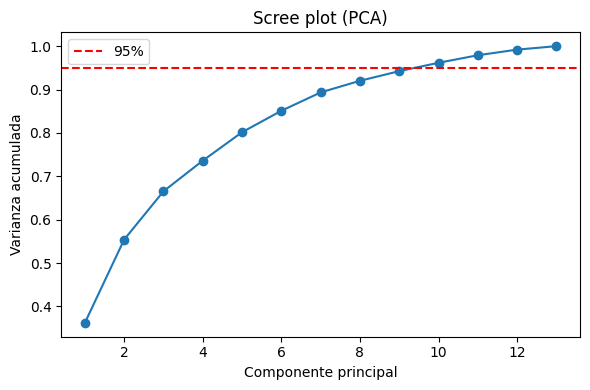

In [ ]:
# 2) Escalar + PCA (≈95% de varianza) --------------------------------
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_full = PCA().fit(X_std)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = int(np.searchsorted(var_acum, 0.95) + 1)
k95 = max(2, k95)  # para poder graficar al menos 2 PCs
print(f"PCs para ≈95% varianza: {k95} (var_acum={var_acum[k95-1]:.2%})")

pca = PCA(n_components=k95, random_state=42)
X_pca = pca.fit_transform(X_std)
# pca_full = PCA().fit(X_std) calcula todas las varianzas explicadas.
# var_acum = np.cumsum(...) acumula la proporción de varianza.
# k95 = int(np.searchsorted(var_acum, 0.95) + 1) busca el primer índice donde la varianza acumulada ≥ 0.95 y le suma 1 (porque los índices empiezan en 0).
# k95 = max(2, k95) garantiza al menos 2 PCs (útil para graficar).
# pca = PCA(n_components=k95) y luego X_pca = pca.fit_transform(X_std) proyecta los datos a esas k95 dimensiones.

# Scree plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(var_acum)+1), var_acum, marker="o")
plt.axhline(0.95, color="r", ls="--", label="95%")
plt.title("Scree plot (PCA)")
plt.xlabel("Componente principal"); plt.ylabel("Varianza acumulada")
plt.legend(); plt.tight_layout(); plt.show()

Eje X – Componentes principales
Cada punto en el eje horizontal representa un componente principal ordenado de mayor a menor importancia (en términos de varianza explicada).

Eje Y – Varianza acumulada
Indica la proporción total de varianza de los datos que queda explicada al ir sumando componentes.

Curva azul
Muestra cómo va creciendo la varianza acumulada a medida que se añaden más componentes principales.

Línea roja discontinua (95%)
Representa un umbral deseado de explicación de varianza. En este caso, se busca cubrir al menos el 95% de la varianza total.

Punto de corte
Observando la curva, se ve que se alcanza el 95% de la varianza acumulada aproximadamente en el componente 10. Esto significa que con los primeros 10 componentes ya se conserva prácticamente toda la información relevante de los datos, y se podrían descartar los demás para reducir dimensionalidad sin perder mucha información.

Conclusión

Si tu objetivo es reducir dimensionalidad, puedes quedarte con los primeros 10 componentes.

Esto reduce el ruido y el costo computacional, manteniendo al mismo tiempo la estructura principal de los datos.

Esta reducción es útil antes de aplicar algoritmos como K-Means, DBSCAN o clustering jerárquico.

Aplicar algoritmos de clustering sobre las nuevas variables
Usas esos 10 componentes como entrada para K-Means, DBSCAN, Ward, etc.
El clustering se beneficia de datos más compactos y menos correlacionados.

[K-Means] Mejor K por silueta: 3 | Sil=0.299


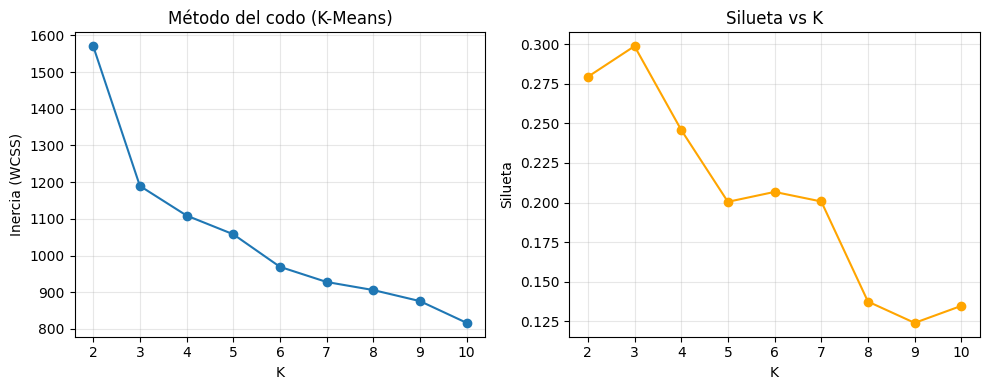

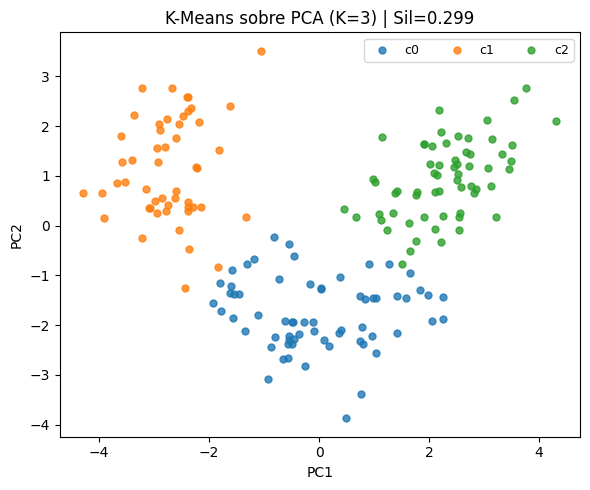

In [ ]:
# 3) K-Means: codo + silueta, clustering final -----------------------
Ks = range(2, 11)
inertias, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    lab = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_pca, lab))

k_best = Ks[int(np.argmax(sils))]
km_best = KMeans(n_clusters=k_best, random_state=42, n_init="auto").fit(X_pca)
lab_km = km_best.labels_
sil_km = silhouette_score(X_pca, lab_km)
print(f"[K-Means] Mejor K por silueta: {k_best} | Sil={sil_km:.3f}")

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(Ks, inertias, marker="o"); ax[0].set_title("Método del codo (K-Means)")
ax[0].set_xlabel("K"); ax[0].set_ylabel("Inercia (WCSS)"); ax[0].grid(alpha=.3)
ax[1].plot(Ks, sils, marker="o", color="orange"); ax[1].set_title("Silueta vs K")
ax[1].set_xlabel("K"); ax[1].set_ylabel("Silueta"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
for c in np.unique(lab_km):
    m = lab_km == c
    plt.scatter(X_pca[m,0], X_pca[m,1], s=25, label=f"c{c}", alpha=.8)
plt.title(f"K-Means sobre PCA (K={k_best}) | Sil={sil_km:.3f}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

1. Método del codo (K-Means)

Eje X: número de clusters
𝐾
K probados (de 2 a 10).

Eje Y: inercia o WCSS (Within-Cluster Sum of Squares), que mide la dispersión interna de los puntos dentro de cada cluster.

Interpretación:

A medida que aumenta
𝐾
K, la inercia disminuye porque más clusters implican grupos más pequeños y compactos.

El “codo” se observa donde la reducción de inercia empieza a ser mucho menor; aquí parece estar alrededor de K = 3 o K = 4.

Esto sugiere que 3 o 4 clusters son un buen balance entre simplicidad y ajuste.

2. Silueta vs K

Eje X: número de clusters
𝐾
K.

Eje Y: score de silueta, que mide qué tan bien están separados los clusters (1 = separación perfecta, 0 = clusters superpuestos).

Interpretación:

El valor máximo se da en K = 3 (~0.300), indicando que esta configuración ofrece la mejor separación relativa.

A partir de
𝐾
>
3
K>3, la silueta disminuye, lo que sugiere que más clusters no mejoran la estructura y podrían fragmentar grupos naturales.

3. Gráfico de dispersión PCA (K = 3)

Ejes: PC1 y PC2 son las dos primeras componentes principales, que resumen la mayor parte de la varianza del dataset.

Colores: cada punto es una observación, y los colores representan los 3 clusters obtenidos por K-Means.

Interpretación:

Se observan tres grupos bastante definidos en el plano PC1–PC2, aunque con cierta superposición entre el azul y el verde.

Esto concuerda con el score de silueta (~0.299), que es moderado: hay una separación clara, pero no perfecta.

El PCA ayuda a visualizar los clusters aunque no se usó toda la varianza (solo lo que captan PC1 y PC2).

Conclusión combinada:

Los tres gráficos indican que K = 3 es una elección sólida, respaldada tanto por el método del codo como por el score de silueta.

La proyección PCA confirma visualmente que existe una estructura de 3 grupos, aunque con algunos límites difusos.

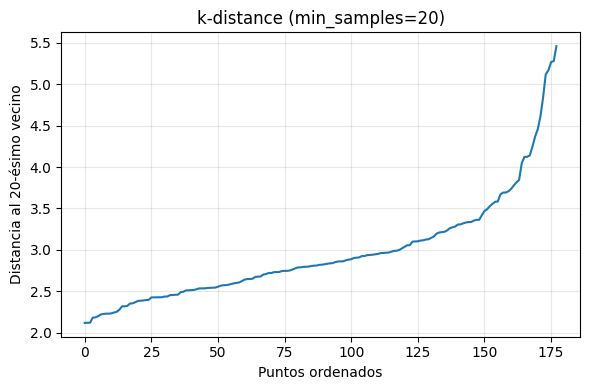

[DBSCAN] eps≈4.263, min_samples=20 | n_clusters=1 | Sil=nan


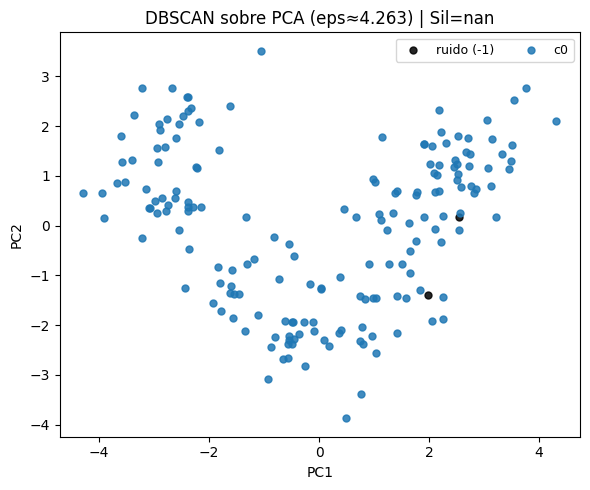

In [ ]:
# 4) DBSCAN: k-distance para eps + clustering ------------------------
# Regla práctica: min_samples ~ 2*dim
min_samples = max(5, 2*X_pca.shape[1])
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_dist)
plt.title(f"k-distance (min_samples={min_samples})")
plt.xlabel("Puntos ordenados"); plt.ylabel(f"Distancia al {min_samples}-ésimo vecino")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# Usa percentil 95 como arranque (ajústalo mirando el 'codo')
eps0 = float(np.percentile(k_dist, 95))
db = DBSCAN(eps=eps0, min_samples=min_samples)
lab_db = db.fit_predict(X_pca)

def safe_silhouette(Z, labels):
    vals = np.unique(labels)
    vals = vals[vals != -1]
    if len(vals) >= 2:
        return silhouette_score(Z, labels[labels != -1])
    return np.nan

sil_db = safe_silhouette(X_pca, lab_db)
ncl_db = len(set(lab_db)) - (1 if -1 in lab_db else 0)
print(f"[DBSCAN] eps≈{eps0:.3f}, min_samples={min_samples} | n_clusters={ncl_db} | Sil={sil_db:.3f}")

plt.figure(figsize=(6,5))
for lab in np.unique(lab_db):
    m = lab_db == lab
    c = "k" if lab == -1 else None
    lbl = "ruido (-1)" if lab == -1 else f"c{lab}"
    plt.scatter(X_pca[m,0], X_pca[m,1], s=25, label=lbl, alpha=.85, c=c)
plt.title(f"DBSCAN sobre PCA (eps≈{eps0:.3f}) | Sil={sil_db:.3f}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

Este gráfico sirve para estimar el parámetro eps de DBSCAN, usando la técnica del k-dist plot.

Eje X: puntos ordenados por la distancia a su k-ésimo vecino más cercano (aquí, el 20º vecino porque min_samples=20).

Eje Y: la distancia a ese vecino.

Interpretación:

En la zona inicial, las distancias suben lentamente: estos puntos están en regiones densas (dentro de clusters).

Hay un punto donde la curva empieza a subir bruscamente (el "codo"): este salto indica que los puntos a la derecha ya están más aislados, y eps debe elegirse alrededor de esa altura.

Aquí el "codo" parece estar cerca de 4.26, que fue el valor usado después.

2. Gráfico de DBSCAN sobre PCA

Objetivo:
Visualizar el resultado del clustering DBSCAN en un espacio reducido a 2 componentes principales (PC1 y PC2).

Ejes: PC1 y PC2 son los dos primeros componentes principales del PCA aplicado a los datos estandarizados.

Colores: indican el cluster asignado por DBSCAN.

El color negro (label -1) representa ruido: puntos que DBSCAN no pudo asignar a ningún cluster.

Aquí solo hay un color azul (c0), lo que significa que DBSCAN detectó un solo cluster más puntos de ruido.

Sil=nan: El Silhouette Score es NaN porque la métrica no se puede calcular cuando solo hay un cluster válido.

Conclusión:

El valor de eps estimado (≈4.263) fue bastante alto para estos datos reducidos con PCA, lo que hizo que DBSCAN agrupara prácticamente todo como un único cluster.

Esto indica que, para este dataset, DBSCAN con este eps no logró separar subgrupos internos.

Si se quiere detectar más de un cluster, sería necesario:

Reducir eps para que el algoritmo sea más estricto.

Ajustar min_samples.

Probar DBSCAN directamente en el espacio original (no reducido) o con más componentes del PCA

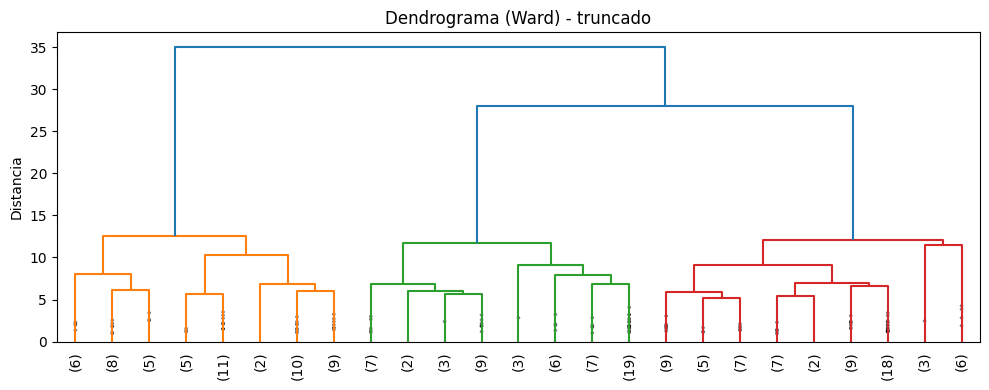

[Ward] k=3 | Sil=0.284


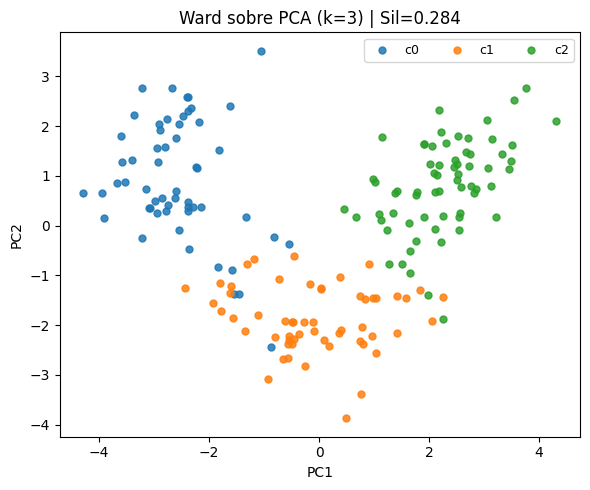

In [ ]:
# 5) Jerárquico (Ward): dendrograma + clustering ---------------------
Z = linkage(X_pca, method='ward')
plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode='lastp', p=25, show_contracted=True, leaf_rotation=90)
plt.title("Dendrograma (Ward) - truncado"); plt.ylabel("Distancia")
plt.tight_layout(); plt.show()

k_h = 3  # elige según el dendrograma
lab_h = fcluster(Z, t=k_h, criterion='maxclust') - 1
sil_h = silhouette_score(X_pca, lab_h)
print(f"[Ward] k={k_h} | Sil={sil_h:.3f}")

plt.figure(figsize=(6,5))
for c in np.unique(lab_h):
    m = lab_h == c
    plt.scatter(X_pca[m,0], X_pca[m,1], s=25, label=f"c{c}", alpha=.85)
plt.title(f"Ward sobre PCA (k={k_h}) | Sil={sil_h:.3f}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()

Dendrograma (método Ward)

Qué es: Es una representación jerárquica de cómo se van formando los clusters en un clustering jerárquico aglomerativo.

Método Ward: Este método fusiona los grupos minimizando el aumento de la varianza total dentro de los clusters.

Ejes:

Eje Y ("Distancia"): representa la disimilitud entre los grupos al momento de unirlos. Una distancia más alta significa que los grupos eran más distintos antes de fusionarse.

Eje X: son las observaciones (o grupos de observaciones). Aquí aparecen en un orden reorganizado para mostrar la jerarquía.

Colores: El dendrograma está cortado en un nivel de distancia que da 3 clusters (naranja, verde y rojo en tu gráfico).

Interpretación:

Los elementos que se unen a baja distancia son más similares.

Las uniones altas indican que los grupos eran muy distintos antes de fusionarse.

Proyección PCA (Ward sobre PCA)

Qué es: Aquí tomaste los datos originales, aplicaste PCA para reducirlos a 2 componentes principales (PC1 y PC2), y luego realizaste el clustering jerárquico (Ward) usando la versión reducida.

Por qué se hace:

El PCA reduce el ruido y permite visualizar datos multivariantes en 2D.

Esto ayuda a ver la estructura de los clusters de manera más clara.

Gráfico:

Ejes: PC1 y PC2 (combinaciones lineales de tus variables originales que capturan la mayor parte de la varianza).

Colores: Cada color representa un cluster encontrado por el método Ward (k=3).

Silhouette (Sil=0.284):

Es una métrica de calidad de clustering (-1 a 1).

0.28 indica que los clusters existen, pero no están muy bien separados (una separación aceptable empieza cerca de 0.5 y buena desde 0.7).

Interpretación visual:

Hay una separación razonable entre azul y verde.

El grupo naranja se solapa un poco con los otros, lo que explica un Silhouette bajo.

Resumen rápido:

Dendrograma → muestra cómo se forman los clusters jerárquicamente y ayuda a decidir el número de grupos.

Ward sobre PCA → proyecta los datos en 2D para visualizar cómo quedaron los clusters finales.

Silhouette=0.284 → sugiere que, aunque hay estructura, no hay una separación muy fuerte entre todos los grupos.

In [ ]:
# 6) Resumen ----------------------------------------------------------
res = pd.DataFrame({
    "Metodo": ["KMeans@PCA", "DBSCAN@PCA", "Ward@PCA"],
    "Clusters": [k_best, ncl_db, k_h],
    "Silueta": [sil_km, sil_db, sil_h]
})
print("\n=== RESUMEN DE MÉTRICAS ===")
print(res)


=== RESUMEN DE MÉTRICAS ===
       Metodo  Clusters   Silueta
0  KMeans@PCA         3  0.298675
1  DBSCAN@PCA         1       NaN
2    Ward@PCA         3  0.283952


KMeans@PCA (3 clusters, Sil=0.2987)

Es el método que obtuvo el silhouette más alto, aunque 0.29 sigue siendo bajo.

Esto sugiere que los clusters existen, pero no están muy separados y puede haber solapamiento entre clases.

KMeans en PCA suele ser bueno cuando la separación es esférica y homogénea, pero aquí la estructura de los datos no es perfecta.

DBSCAN@PCA (1 cluster, NaN)

Detectó un único cluster → significa que con los parámetros usados, DBSCAN considera que todos los puntos forman parte de la misma agrupación o están como ruido.

Esto pasa cuando:

El parámetro eps es muy grande (agrupa todo).

La densidad no es suficientemente diferenciada.

No aporta partición útil en este caso.

Ward@PCA (3 clusters, Sil=0.2840)

Similar a KMeans en número de clusters y rendimiento.

El valor de silhouette también es bajo, lo que confirma que no hay una separación clara en el espacio reducido por PCA.

Puede que en el espacio original (sin reducción PCA) los resultados cambien.

Conclusiones generales de tu dataset

Separación moderada: Los valores de silhouette (~0.28-0.30) indican que los clusters no son completamente distinguibles y hay bastante solapamiento entre ellos.

PCA conserva información, pero limita la separación: Reducir a 2 componentes para graficar ayuda a visualizar, pero también puede perder información relevante para la separación de clases.

DBSCAN no funciona bien en este caso con los parámetros actuales → requiere ajuste de eps y min_samples para detectar subgrupos.

Posible mejora:

Probar clustering sin PCA (usando todas las variables).

Usar más componentes en PCA (por ejemplo, 5-10) antes de clustering.

Ajustar hiperparámetros de DBSCAN o usar algoritmos como HDBSCAN.

In [ ]:
# CLUSTERING COMPARATIVO (Wine): KMeans, Ward, DBSCAN
# con y sin PCA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import linkage, dendrogram

# ----------------------------
# 0) Datos y preprocesado base
# ----------------------------
wine = load_wine()
X = wine.data
feature_names = wine.feature_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# PCA para CLUSTERING (mantener estructura): 10 componentes
pca10 = PCA(n_components=min(10, X.shape[1]), random_state=42)
X_pca10 = pca10.fit_transform(X_std)

# PCA para GRÁFICO 2D
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_std)

print(f"Shape sin PCA: {X_std.shape} | con PCA(10): {X_pca10.shape}")

# -------------------------------------------------
# Helpers
# -------------------------------------------------
def best_k_by_silhouette(X_in, k_range=range(2, 11), method="kmeans"):
    """Devuelve (mejor_k, lista_sil) para un rango de K."""
    sils = []
    for k in k_range:
        if method == "kmeans":
            model = KMeans(n_clusters=k, random_state=42, n_init="auto")
        elif method == "ward":
            model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        else:
            raise ValueError("method debe ser 'kmeans' o 'ward'")
        labels = model.fit_predict(X_in)
        sil = silhouette_score(X_in, labels)
        sils.append(sil)
    best_k = k_range[int(np.argmax(sils))]
    return best_k, sils

def safe_silhouette(X_in, labels):
    """Silhouette solo si hay >=2 clusters válidos."""
    uniq = np.unique(labels)
    if len(uniq) <= 1 or (len(uniq) == 2 and -1 in uniq):
        return np.nan
    return silhouette_score(X_in, labels)

def plot_clustering_2d(X2, labels, title, centers=None):
    plt.figure(figsize=(6,5))
    uniq = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(2, len(uniq))))
    for i, lab in enumerate(uniq):
        m = labels == lab
        lbl = f"c{lab}" if lab != -1 else "ruido (-1)"
        c = "k" if lab == -1 else colors[i]
        plt.scatter(X2[m,0], X2[m,1], s=24, label=lbl, c=[c], alpha=0.85)
    if centers is not None:
        C2 = pca2.transform(centers)  # proyectamos al plano 2D para dibujarlos
        plt.scatter(C2[:,0], C2[:,1], c="k", s=160, marker="X", label="centroides")
    plt.title(title); plt.legend(ncol=3, fontsize=9); plt.tight_layout(); plt.show()


Shape sin PCA: (178, 13) | con PCA(10): (178, 10)


[KMeans] sin PCA  -> K=3 | Sil=0.285
[KMeans] con PCA10 -> K=3 | Sil=0.299


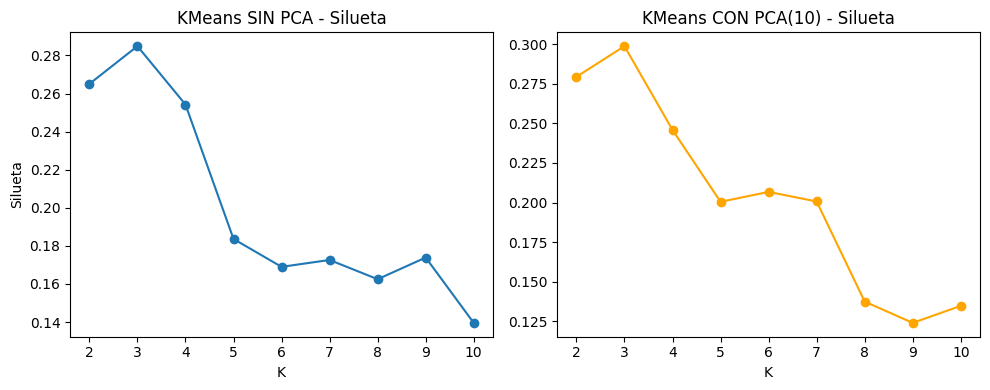

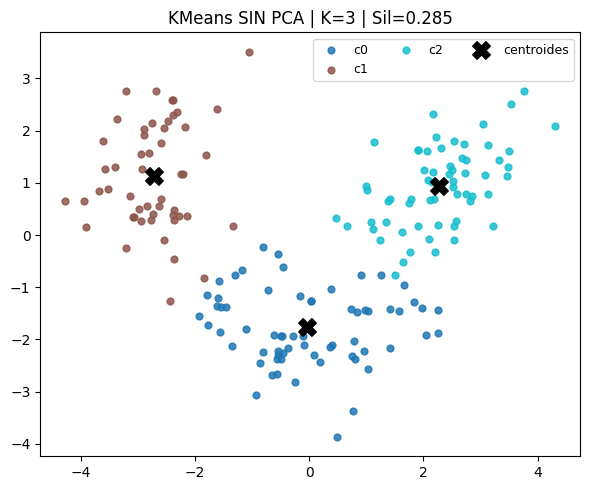

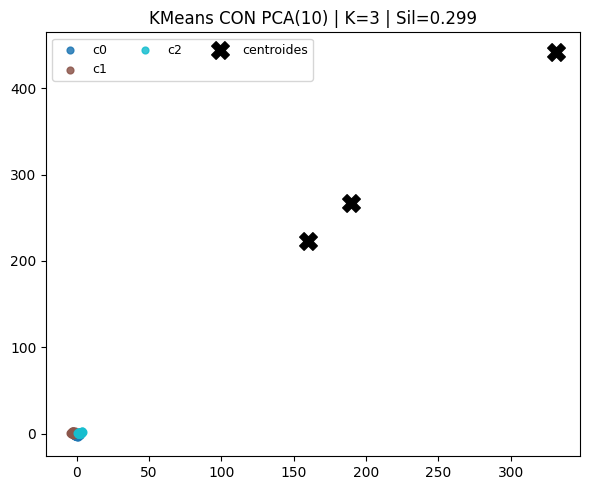

In [ ]:
# 1) K-MEANS (sin PCA vs con PCA)
# -------------------------------------------------
k_range = range(2, 11)

k_best_raw, sils_raw = best_k_by_silhouette(X_std, k_range, method="kmeans")
k_best_pca, sils_pca = best_k_by_silhouette(X_pca10, k_range, method="kmeans")

km_raw  = KMeans(n_clusters=k_best_raw, random_state=42, n_init="auto").fit(X_std)
km_pca  = KMeans(n_clusters=k_best_pca, random_state=42, n_init="auto").fit(X_pca10)

sil_raw = silhouette_score(X_std, km_raw.labels_)
sil_pca = silhouette_score(X_pca10, km_pca.labels_)

print(f"[KMeans] sin PCA  -> K={k_best_raw} | Sil={sil_raw:.3f}")
print(f"[KMeans] con PCA10 -> K={k_best_pca} | Sil={sil_pca:.3f}")

# Gráficos de selección por silueta
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(k_range, sils_raw, marker="o"); ax[0].set_title("KMeans SIN PCA - Silueta"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Silueta")
ax[1].plot(k_range, sils_pca, marker="o", color="orange"); ax[1].set_title("KMeans CON PCA(10) - Silueta"); ax[1].set_xlabel("K")
plt.tight_layout(); plt.show()

# Proyección 2D para visualizar
plot_clustering_2d(X_pca2, km_raw.labels_,  f"KMeans SIN PCA | K={k_best_raw} | Sil={sil_raw:.3f}", centers=km_raw.cluster_centers_)
plot_clustering_2d(X_pca2, km_pca.labels_,  f"KMeans CON PCA(10) | K={k_best_pca} | Sil={sil_pca:.3f}", centers=scaler.inverse_transform(pca10.inverse_transform(km_pca.cluster_centers_)))

1. KMeans SIN PCA (izquierda)

Ejes: Las coordenadas son las 2 primeras componentes principales calculadas solo para graficar, pero el clustering se hizo en el espacio original de todas las variables.

Colores: Representan los tres clústeres detectados (c0, c1, c2).

Cruces negras (centroides): Posiciones promedio de cada clúster en el espacio proyectado.

Silhouette = 0.285:

Es un valor bajo, indicando que la separación entre grupos no es muy clara y hay bastante solapamiento.

Un valor cercano a 0 significa que los puntos están tan cerca de su propio clúster como de otros, lo que reduce la calidad de la segmentación.

Observación: Aunque hay cierta separación, especialmente entre el clúster marrón y los demás, se ve solapamiento entre el azul oscuro y el celeste.

2. KMeans CON PCA(10) (derecha)

Ejes: Aquí la situación es distinta:

El clustering se hizo después de reducir la dimensionalidad a 10 componentes principales (PCA(10)).

El gráfico que ves no está mostrando PC1 vs PC2 sino probablemente los valores en el espacio reducido, y por eso los centroides aparecen muy alejados en una escala distinta.

Colores: Los mismos clústeres detectados (c0, c1, c2) después de PCA(10).

Silhouette = 0.299:

Mejora mínima respecto al anterior (0.285 → 0.299).

Esto indica que reducir a 10 componentes ayudó un poco a separar los grupos, pero la ganancia no es muy grande.

Observación: Es posible que la visualización no sea intuitiva porque no estás viendo las primeras dos componentes, sino un plano arbitrario. Por eso los centroides aparecen tan alejados (debido a la escala de PCA).

Conclusión general

Ambos métodos encuentran 3 grupos similares, con calidad baja-media (Silhouette ~0.29).

La reducción a PCA(10) mejora ligeramente la métrica, pero no cambia de forma drástica la estructura de los clústeres.

El solapamiento indica que quizá:

El dataset no tiene clústeres bien definidos.

Sería útil probar técnicas no lineales como t-SNE o UMAP para exploración visual.

Podrías también probar ajustar K para ver si otra cantidad de clústeres mejora la separación.

[Ward]  sin PCA  -> K=3 | Sil=0.277
[Ward]  con PCA10 -> K=3 | Sil=0.284


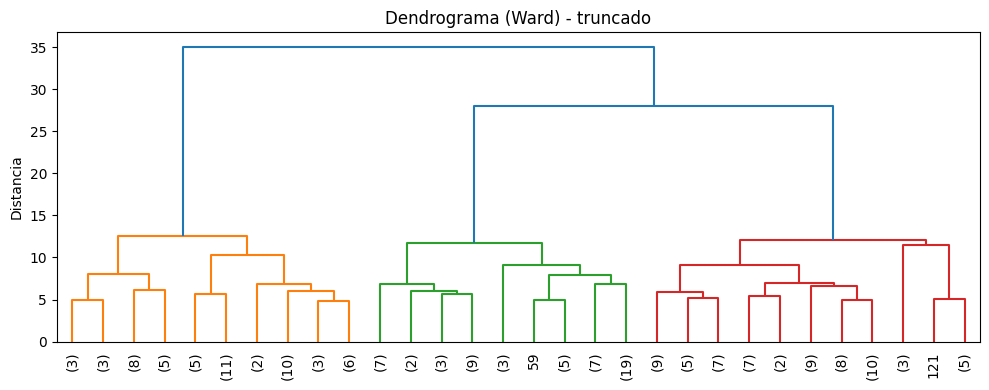

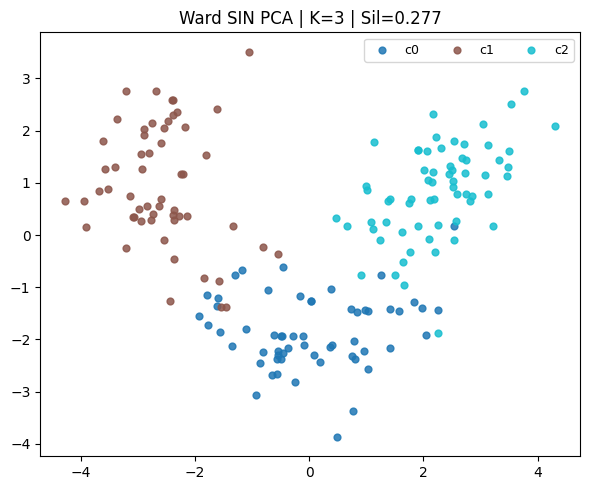

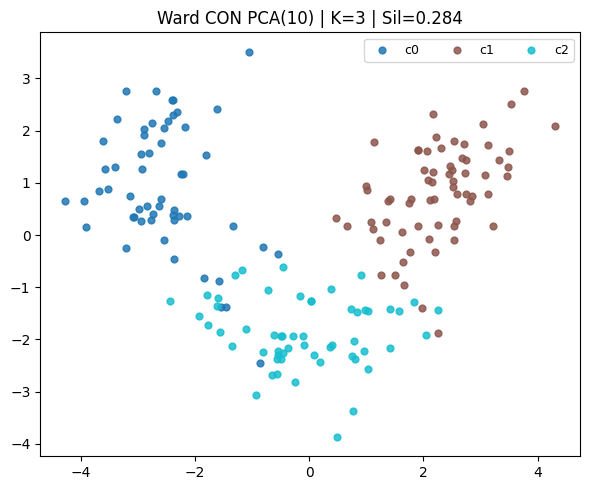

In [ ]:
# -------------------------------------------------
# 2) JERÁRQUICO (Ward) sin y con PCA
# -------------------------------------------------
k_best_raw_w, sils_raw_w = best_k_by_silhouette(X_std, k_range, method="ward")
k_best_pca_w, sils_pca_w = best_k_by_silhouette(X_pca10, k_range, method="ward")

ward_raw = AgglomerativeClustering(n_clusters=k_best_raw_w, linkage="ward").fit(X_std)
ward_pca = AgglomerativeClustering(n_clusters=k_best_pca_w, linkage="ward").fit(X_pca10)

sil_raw_w = silhouette_score(X_std, ward_raw.labels_)
sil_pca_w = silhouette_score(X_pca10, ward_pca.labels_)

print(f"[Ward]  sin PCA  -> K={k_best_raw_w} | Sil={sil_raw_w:.3f}")
print(f"[Ward]  con PCA10 -> K={k_best_pca_w} | Sil={sil_pca_w:.3f}")

# Dendrograma (truncado) en espacio PCA para visualización
Z = linkage(X_pca10, method="ward")
plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Dendrograma (Ward) - truncado"); plt.ylabel("Distancia"); plt.tight_layout(); plt.show()

# Proyección 2D
plot_clustering_2d(X_pca2, ward_raw.labels_, f"Ward SIN PCA | K={k_best_raw_w} | Sil={sil_raw_w:.3f}")
plot_clustering_2d(X_pca2, ward_pca.labels_, f"Ward CON PCA(10) | K={k_best_pca_w} | Sil={sil_pca_w:.3f}")

Ward SIN PCA

Silhouette: 0.277 → indica que la separación entre clusters es moderada, con cierto solapamiento entre grupos.

Interpretación visual:

Los tres colores representan los tres clusters encontrados.

Aunque hay cierta separación, se observa que algunos puntos están cerca de la frontera y podrían pertenecer a más de un cluster según la métrica de distancia.

El cluster marrón (c1) está bien definido a la izquierda, pero los clusters azul (c0) y celeste (c2) tienen áreas de solapamiento en la zona central.

2️⃣ Ward CON PCA (10 componentes)

Silhouette: 0.284 → mejora ligera respecto al caso sin PCA.

Interpretación visual:

La reducción a 10 componentes PCA parece mejorar un poco la separación, probablemente eliminando ruido y redundancia en las variables originales.

Los clusters están más compactos y la frontera entre azul y celeste (c0 y c2) es más clara.

El grupo marrón (c1) se desplaza más y aparece más definido a la derecha.

📊 Conclusión comparativa:

Ward + PCA(10) logra una separación ligeramente mejor y más limpia, según la métrica de Silhouette (0.284 vs 0.277).

La diferencia no es enorme, pero sí consistente: la reducción de dimensionalidad ayuda a que el algoritmo capture mejor la estructura subyacente de los datos.

Sin embargo, el valor de Silhouette < 0.3 indica que la estructura de clusters no es muy fuerte, lo que podría significar que el dataset no tiene separaciones muy marcadas en 3 grupos o que sería útil probar con otro número de clusters o métodos de agrupamiento.

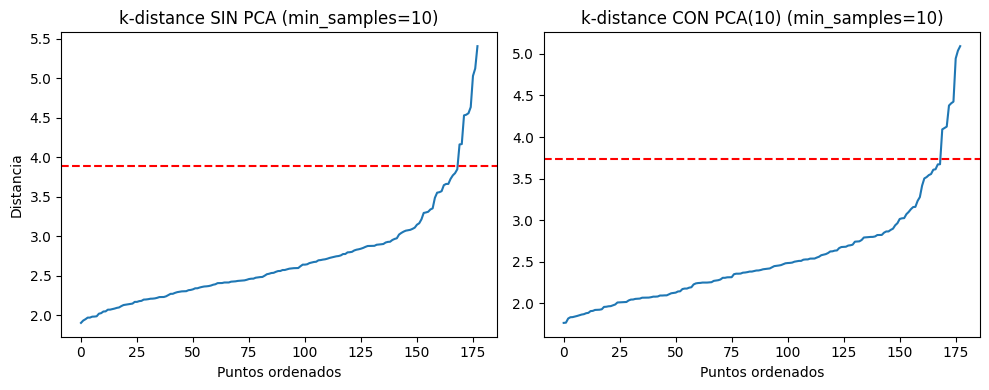

[DBSCAN] SIN PCA  -> eps≈3.894 | clusters=1 | Sil=nan
[DBSCAN] CON PCA10 -> eps≈3.736 | clusters=1 | Sil=nan


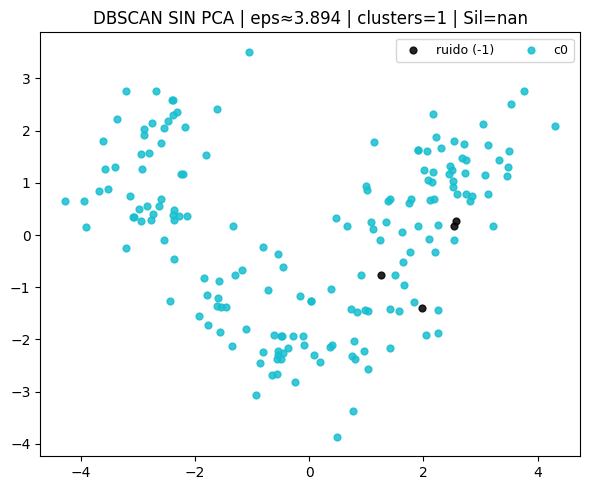

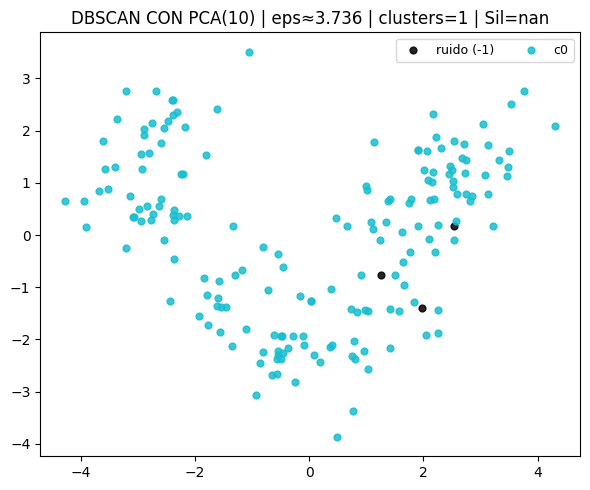

In [ ]:
# -------------------------------------------------
# 3) DBSCAN (sin y con PCA): eps por k-distance
# -------------------------------------------------
def k_distance_plot(X_in, min_samples=10):
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_in)
    distances, _ = nbrs.kneighbors(X_in)
    k_dist = np.sort(distances[:, -1])
    return k_dist

min_samples = 10
kdist_raw  = k_distance_plot(X_std,   min_samples=min_samples)
kdist_pca  = k_distance_plot(X_pca10, min_samples=min_samples)

eps_raw = float(np.percentile(kdist_raw, 95))
eps_pca = float(np.percentile(kdist_pca, 95))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(kdist_raw); ax[0].axhline(eps_raw, ls="--", c="r"); ax[0].set_title(f"k-distance SIN PCA (min_samples={min_samples})"); ax[0].set_ylabel("Distancia"); ax[0].set_xlabel("Puntos ordenados")
ax[1].plot(kdist_pca); ax[1].axhline(eps_pca, ls="--", c="r"); ax[1].set_title(f"k-distance CON PCA(10) (min_samples={min_samples})"); ax[1].set_xlabel("Puntos ordenados")
plt.tight_layout(); plt.show()

db_raw = DBSCAN(eps=eps_raw, min_samples=min_samples)
db_pca = DBSCAN(eps=eps_pca, min_samples=min_samples)

lab_db_raw = db_raw.fit_predict(X_std)
lab_db_pca = db_pca.fit_predict(X_pca10)

sil_db_raw = safe_silhouette(X_std, lab_db_raw)
sil_db_pca = safe_silhouette(X_pca10, lab_db_pca)

ncl_raw = len(set(lab_db_raw)) - (1 if -1 in lab_db_raw else 0)
ncl_pca = len(set(lab_db_pca)) - (1 if -1 in lab_db_pca else 0)

print(f"[DBSCAN] SIN PCA  -> eps≈{eps_raw:.3f} | clusters={ncl_raw} | Sil={sil_db_raw}")
print(f"[DBSCAN] CON PCA10 -> eps≈{eps_pca:.3f} | clusters={ncl_pca} | Sil={sil_db_pca}")

plot_clustering_2d(X_pca2, lab_db_raw, f"DBSCAN SIN PCA | eps≈{eps_raw:.3f} | clusters={ncl_raw} | Sil={sil_db_raw}")
plot_clustering_2d(X_pca2, lab_db_pca, f"DBSCAN CON PCA(10) | eps≈{eps_pca:.3f} | clusters={ncl_pca} | Sil={sil_db_pca}")

En tus resultados de DBSCAN, tanto sin PCA como con PCA(10), la interpretación es la siguiente:

Número de clusters detectados:

Ambos casos detectaron solo 1 clúster (etiqueta c0) y algunos puntos como ruido (-1, en negro).

Esto significa que, con los parámetros usados (eps grande y min_samples por defecto), el algoritmo consideró que todos los puntos están lo suficientemente cerca como para formar un solo grupo, salvo unos pocos considerados atípicos.

Coeficiente de silueta (Sil=nan):

No se puede calcular porque el coeficiente de silueta requiere al menos dos clústeres distintos.

Por eso el valor aparece como NaN.

Efecto del PCA:

Usar PCA con 10 componentes no cambió el número de clústeres detectados, ni la distribución visual, ya que DBSCAN con esos parámetros sigue agrupando todo en un único clúster.

En otras palabras, PCA aquí no mejoró la separación.

Conclusión:

Con estos parámetros, DBSCAN no está segmentando bien tu dataset Wine.

Sería necesario ajustar eps y min_samples para encontrar un patrón más granular y que surjan varios clústeres.

Este resultado confirma que KMeans y Ward fueron más efectivos para segmentar tu data, aunque con siluetas bajas (~0.28–0.30).

In [ ]:
# -------------------------------------------------
# 4) Resumen comparativo
# -------------------------------------------------
res = []
res.append(["KMeans@RAW",  k_best_raw,    sil_raw])
res.append(["KMeans@PCA",  k_best_pca,    sil_pca])
res.append(["Ward@RAW",    k_best_raw_w,  sil_raw_w])
res.append(["Ward@PCA",    k_best_pca_w,  sil_pca_w])
res.append(["DBSCAN@RAW",  ncl_raw,       sil_db_raw])
res.append(["DBSCAN@PCA",  ncl_pca,       sil_db_pca])

df_res = pd.DataFrame(res, columns=["Método","Clusters","Silueta"]).sort_values("Silueta", ascending=False)
print("\n=== RESUMEN DE MÉTRICAS ===")
print(df_res.to_string(index=False))


=== RESUMEN DE MÉTRICAS ===
    Método  Clusters  Silueta
KMeans@PCA         3 0.298675
KMeans@RAW         3 0.284859
  Ward@PCA         3 0.283952
  Ward@RAW         3 0.277444
DBSCAN@RAW         1      NaN
DBSCAN@PCA         1      NaN


Si aplicas PCA y luego usas esas nuevas variables (componentes principales) con KMeans, Ward, DBSCAN u otros métodos, la interpretación cambia bastante, porque:
1️⃣ Qué representan las nuevas variables de PCA

Cada componente principal es una combinación lineal de todas tus variables originales.

Ejemplo:PC1=0.42⋅Alcohol+0.31⋅Acido_malico−0.12⋅Magnesio+…

La idea es que el primer componente explica la mayor varianza posible, el segundo explica la mayor varianza restante y así sucesivamente, manteniendo ortogonalidad (no correlación) entre ellos.

2️⃣ Consecuencias para la interpretación

Pierdes interpretabilidad directa en términos de las variables originales.

No podrás decir “este clúster tiene alto nivel de Alcohol y bajo de Magnesio” de forma directa, porque el espacio en el que trabajas ya está transformado.

Para recuperar algo de interpretabilidad, debes mirar las cargas (loadings) de cada variable en cada componente.

Ganas eficiencia computacional y menos ruido, porque:

Reduces dimensionalidad → menos variables para procesar.

Eliminas colinealidad → los algoritmos funcionan mejor.

Puedes filtrar el ruido conservando solo componentes con varianza significativa.

3️⃣ Ejemplo en tu caso del Wine Dataset

Si aplicas PCA y tomas, por ejemplo, 10 componentes que expliquen el 95 % de la varianza, esos 10 resumen toda la información de las 13 variables originales.

Luego, si usas KMeans o Ward sobre esos 10 PCs:

Los clústeres se forman en un espacio transformado.

Para entenderlos, tienes que mirar qué variables originales contribuyen más a cada PC, y así inferir qué características dominan en cada grupo.

4️⃣ Recomendación práctica

Si tu objetivo es máxima interpretabilidad → trabaja sin PCA o con PCA pero revisando las cargas para traducir resultados a variables originales.

Si tu objetivo es mejor rendimiento y menos ruido → aplica PCA y trabaja en ese espacio reducido, sabiendo que la interpretación final es más abstracta.